In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
!pip install piecewise_regression
import piecewise_regression
from sklearn.metrics import silhouette_score

jugador                         0
season                          0
Posicion                        0
total_intentos                  0
partidos_jugados                0
intentos_aro                    0
intentos_cerca                  0
intentos_media_distancia        0
intentos_triple                 0
intentos_tiro_libre             0
acierto_aro                     0
acierto_cerca                   1
acierto_media_distancia        10
acierto_triple                269
acierto_tiro_libre              0
proporcion_aro                  0
proporcion_cerca                0
proporcion_media_distancia      0
proporcion_triple               0
proporcion_tiro_libre           0
porcentaje_acierto_global       0
altura                          0
edad                            0
peso                            0
dtype: int64
Varianza explicada por componente (%):
[51.14429728 22.81362967]


                              PC1    PC2
proporcion_aro             -0.529 -0.157
proporcion_cerca      

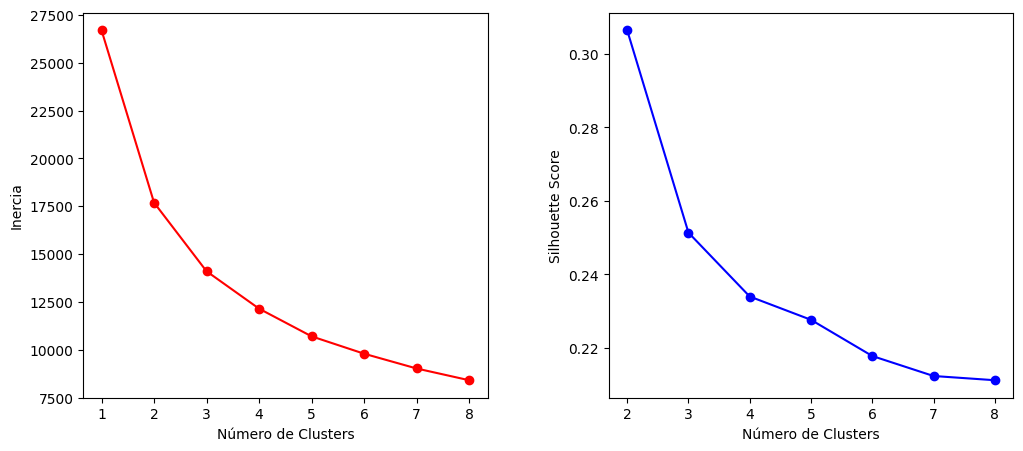

In [36]:
#importo los datos los escalo y aplico un pca
datos_jugadores =pd.read_csv("datos_jugador.csv")
print(datos_jugadores.isnull().sum())
datos_jugadores =datos_jugadores.fillna(0)# solo faltaban casos para las variables de aciertos que serían literalmente 0, asi que no hace falta analizar profundamente
dist_tiros =["proporcion_aro", "proporcion_cerca", "proporcion_media_distancia", "proporcion_triple", "proporcion_tiro_libre"]

escalador =StandardScaler()
datos_escalados =escalador.fit_transform(datos_jugadores[dist_tiros])
pca =PCA(n_components =2)
coordenadas =pca.fit_transform(datos_escalados)
datos_jugadores["PC1"] =coordenadas[:, 0]
datos_jugadores["PC2"] =coordenadas[:, 1]
print("Varianza explicada por componente (%):")
print(pca.explained_variance_ratio_ * 100)

componentes_df = pd.DataFrame(pca.components_.T, index=dist_tiros, columns=["PC1", "PC2"])
print("\n")
print(componentes_df.round(3))
print("\n")
componentes_principales =datos_jugadores[["PC1", "PC2"]]
print("\n")
inercia = []
for i in range(1, 9):
    modelo = KMeans(n_clusters=i, random_state=333, n_init=10)
    modelo.fit(datos_escalados)
    inercia.append(modelo.inertia_)

sil_scores = []
for i in range(2, 9):
    modelo = KMeans(n_clusters=i, random_state=333, n_init=10)
    etiquetas = modelo.fit_predict(datos_escalados)
    puntuacion = silhouette_score(datos_escalados, etiquetas)
    sil_scores.append(puntuacion)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(wspace=0.3)

ax1.plot(range(1, 9), inercia, marker="o", color="red")
ax1.set_xlabel("Número de Clusters")
ax1.set_ylabel("Inercia")

ax2.plot(range(2, 9), sil_scores, marker="o", color="blue")
ax2.set_xlabel("Número de Clusters")
ax2.set_ylabel("Silhouette Score")
plt.show()


Medias ponderadas por cluster:
                                   0         1         2         3
proporcion_aro                 0.175     0.126     0.367     0.213
proporcion_cerca               0.131     0.095     0.210     0.174
proporcion_media_distancia     0.322     0.169     0.100     0.136
proporcion_triple              0.169     0.477     0.039     0.273
proporcion_tiro_libre          0.204     0.133     0.284     0.204
altura                         1.983     1.966     2.071     1.979
peso                         216.263   210.474   242.210   214.682
season                      2015.350  2018.321  2016.922  2019.079
acierto_aro                    0.645     0.642     0.690     0.662
acierto_cerca                  0.424     0.405     0.433     0.422
acierto_media_distancia        0.420     0.402     0.373     0.385
acierto_triple                 0.353     0.372     0.281     0.347
acierto_tiro_libre             0.811     0.806     0.666     0.775

tabla cluster por posicion:
P

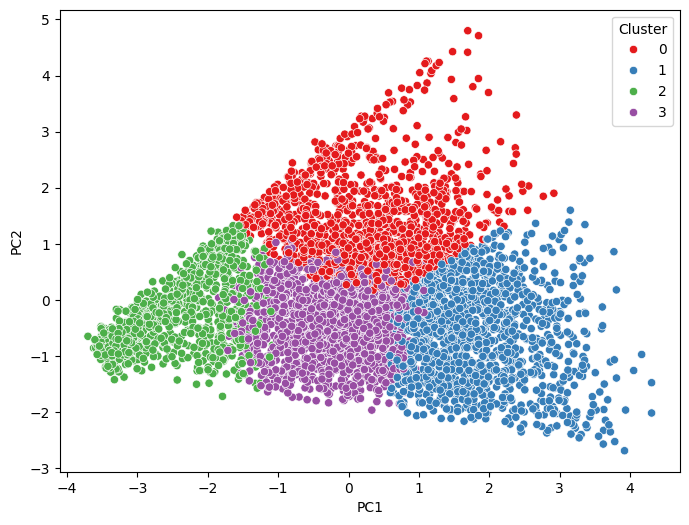

In [37]:
#hago ahora el clustering
tiros_dist =datos_escalados
modelo =KMeans(n_clusters =4, random_state =333, n_init =10)
datos_jugadores["Cluster"] =modelo.fit_predict(tiros_dist)
resumen =[]

#voy a calcular las medias de cada cluster para todos los casos.
for i in range(4):
    df_i =datos_jugadores[datos_jugadores["Cluster"] ==i]
    a ={}
    medias =["proporcion_aro", "proporcion_cerca", "proporcion_media_distancia", "proporcion_triple", "proporcion_tiro_libre", "altura", "peso", "season"]
    for col in medias:
        a[col] =df_i[col].mean()

    tipos_tiro =["aro", "cerca", "media_distancia", "triple", "tiro_libre"]
    for tiro in tipos_tiro:
        intentos =df_i[f"intentos_{tiro}"].sum()
        a[f"acierto_{tiro}"] =(df_i[f"acierto_{tiro}"] * df_i[f"intentos_{tiro}"]).sum() / intentos

    resumen.append(a)

resumen_clusters =pd.DataFrame(resumen)

print("\nMedias ponderadas por cluster:")
print(resumen_clusters.T.round(3))

#hago tablas para ver como se distribuyen las posiciones por cluster y los clusteres por posiciones.
dist_cluster =pd.crosstab(datos_jugadores["Cluster"], datos_jugadores["Posicion"], normalize ="index") * 100

print("\ntabla cluster por posicion:")
print(dist_cluster.round(1))

dist_posiciones =pd.crosstab(datos_jugadores["Cluster"], datos_jugadores["Posicion"], normalize ="columns") * 100

print("\n tabla posicion por cluster:")
print(dist_posiciones.round(1))

# ploteo el cluster usando como ejes las PCS
plt.figure(figsize =(8, 6))
sns.scatterplot(data =datos_jugadores, x ="PC1", y ="PC2", hue ="Cluster", palette ="Set1")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



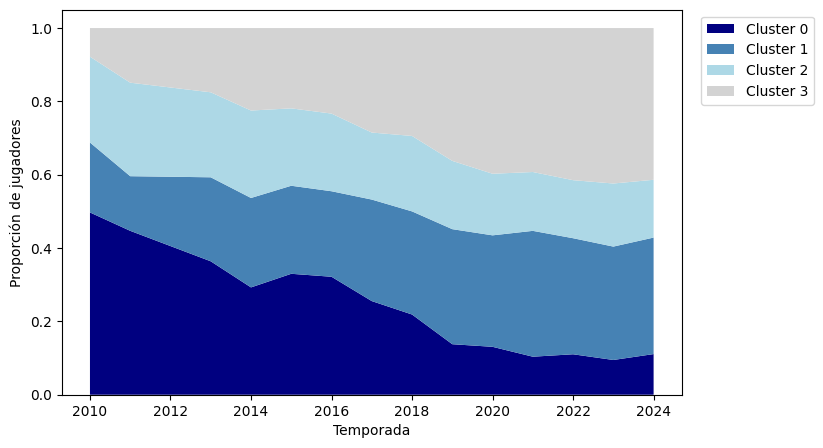

Total jugadores en 2010: 346

Clúster 0: 172 jugadores (49.71%)
Clúster 1: 66 jugadores (19.08%)
Clúster 2: 81 jugadores (23.41%)
Clúster 3: 27 jugadores (7.80%)
Total jugadores en 2024: 406

Clúster 0: 45 jugadores (11.08%)
Clúster 1: 129 jugadores (31.77%)
Clúster 2: 64 jugadores (15.76%)
Clúster 3: 168 jugadores (41.38%)


In [38]:
#voy a hacer ahora un gráfico para ver como ha ido cambiando la distribución en los clusters con el paso de las temporadas
graf_evol =pd.crosstab(datos_jugadores["season"], datos_jugadores["Cluster"], normalize="index")
colores =["navy", "steelblue", "lightblue", "lightgray"]
plt.figure(figsize=(8, 5))
plt.stackplot(graf_evol.index, [graf_evol[i] for i in range(4)], labels=[f"Cluster {i}" for i in range(4)], colors=colores)
plt.xlabel("Temporada")
plt.ylabel("Proporción de jugadores")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()
#aprovecho aqui para calcular el porcentaje de los jugadores que hay en cada cluster en 2010 y 2024 para su uso en la memoria
temp_inicial = datos_jugadores[datos_jugadores["season"] == 2010]
total_jugadores_2010 = len(temp_inicial)

print(f"Total jugadores en 2010: {total_jugadores_2010}\n")
for i in range(4):
  cantidad = len(temp_inicial[temp_inicial["Cluster"] == i])
  porcentaje = (cantidad / total_jugadores_2010) * 100
  print(f"Clúster {i}: {cantidad} jugadores ({porcentaje:.2f}%)")

temp_final = datos_jugadores[datos_jugadores["season"] == 2024]
total_jugadores_2024 = len(temp_final)
print(f"Total jugadores en 2024: {total_jugadores_2024}\n")
for i in range(4):
  cantidad = len(temp_final[temp_final["Cluster"] == i])
  porcentaje = (cantidad / total_jugadores_2024) * 100
  print(f"Clúster {i}: {cantidad} jugadores ({porcentaje:.2f}%)")


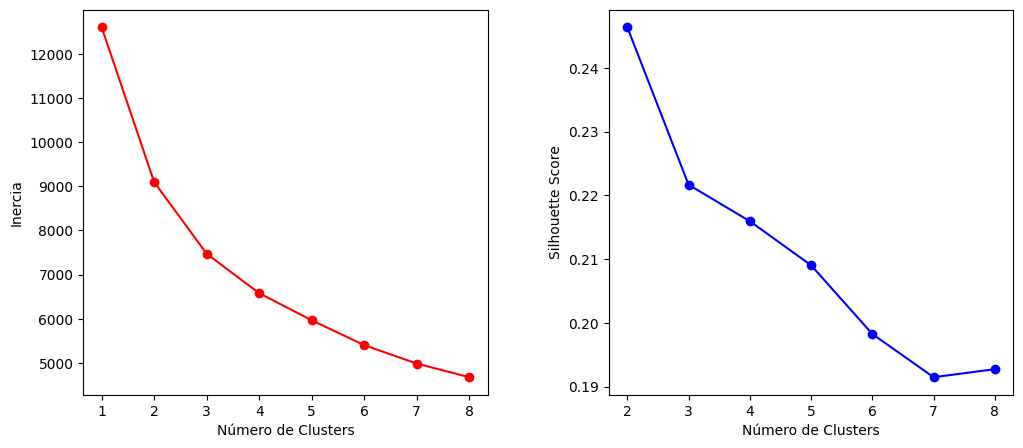

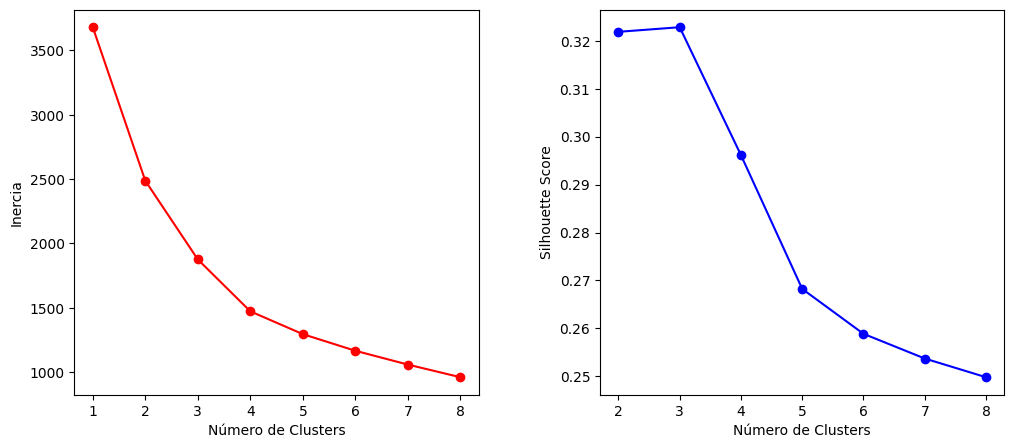

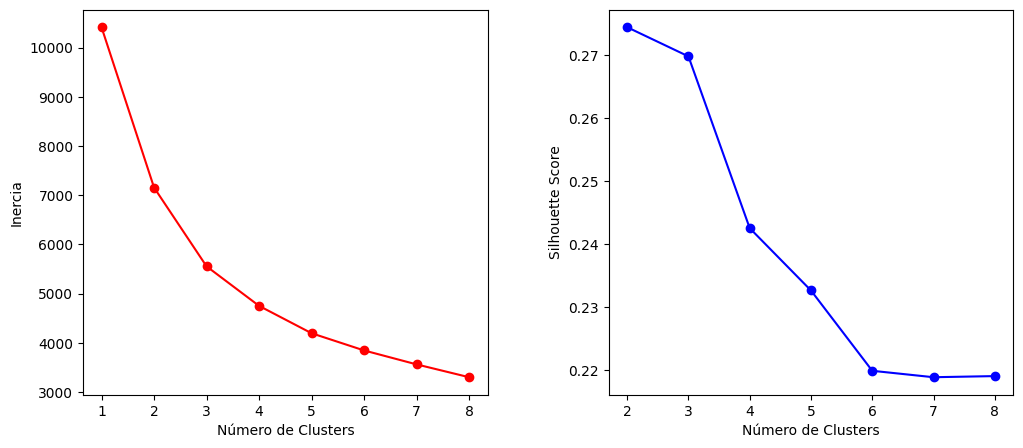

In [39]:
#estudio ahora el numero de clusters para los grupos por posiciones
posiciones_grupos = [
    ("guards", ["G", "G-F"]),
    ("centers", ["C", "C-F"]),
    ("aleros", ["F", "F-G", "F-C"])
]

for nombre_grupo, posiciones in posiciones_grupos:
    df_grupo = datos_jugadores[datos_jugadores["Posicion"].isin(posiciones)].copy()
    escalador_grupo = StandardScaler()
    datos_escalados_grupo = escalador_grupo.fit_transform(df_grupo[dist_tiros])

    inercia = []
    for i in range(1, 9):
        modelo = KMeans(n_clusters=i, random_state=333, n_init=10)
        modelo.fit(datos_escalados_grupo)
        inercia.append(modelo.inertia_)

    sil_scores = []
    for i in range(2, 9):
        modelo = KMeans(n_clusters=i, random_state=333, n_init=10)
        etiquetas = modelo.fit_predict(datos_escalados_grupo)
        puntuacion = silhouette_score(datos_escalados_grupo, etiquetas)
        sil_scores.append(puntuacion)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.subplots_adjust(wspace=0.3)

    ax1.plot(range(1, 9), inercia, marker="o", color="red")
    ax1.set_xlabel("Número de Clusters")
    ax1.set_ylabel("Inercia")


    ax2.plot(range(2, 9), sil_scores, marker="o", color="blue")
    ax2.set_xlabel("Número de Clusters")
    ax2.set_ylabel("Silhouette Score")


    plt.show()


GRUPO: GUARDS
Silhouette Score (guards): 0.2217

Medias ponderadas cluster:
                                   0         1         2
proporcion_aro                 0.141     0.120     0.232
proporcion_cerca               0.131     0.098     0.169
proporcion_media_distancia     0.297     0.169     0.147
proporcion_triple              0.248     0.482     0.232
proporcion_tiro_libre          0.184     0.130     0.219
altura                         1.914     1.930     1.928
peso                         197.019   201.966   201.391
season                      2016.841  2018.678  2017.952
acierto_aro                    0.625     0.635     0.630
acierto_cerca                  0.428     0.401     0.398
acierto_media_distancia        0.421     0.399     0.381
acierto_triple                 0.360     0.373     0.341
acierto_tiro_libre             0.828     0.811     0.784

tabla cluster por posicion:
Posicion     G   G-F
Cluster             
0         83.6  16.4
1         76.0  24.0
2         79

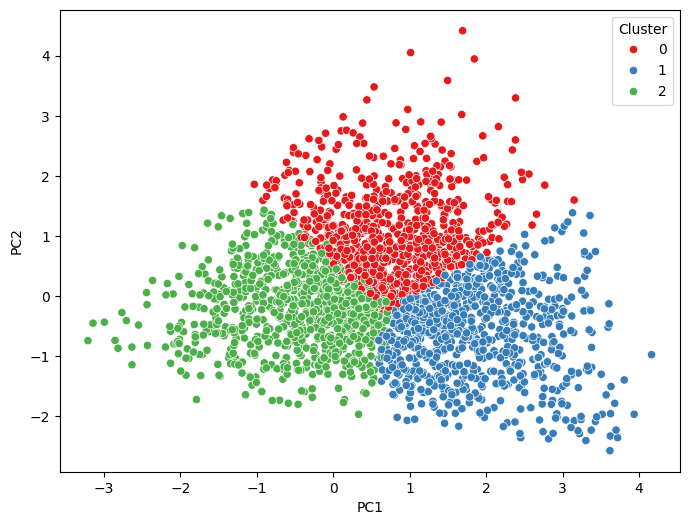

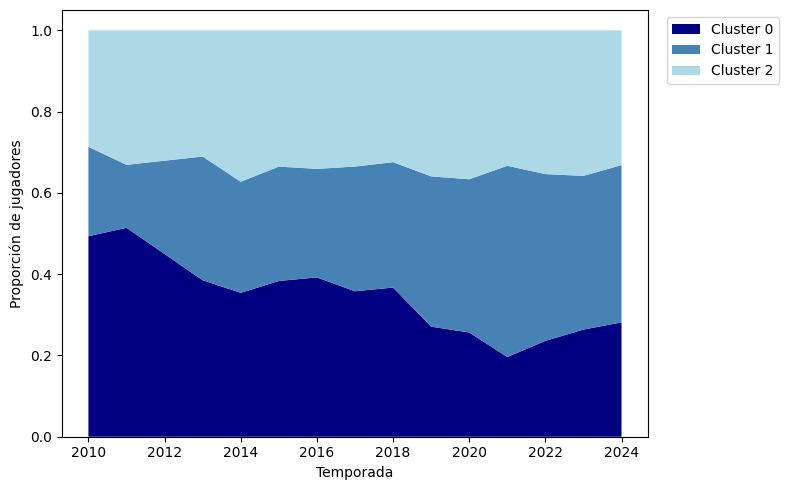


GRUPO: CENTERS
Silhouette Score (centers): 0.3228

Medias ponderadas cluster:
                                   0         1         2
proporcion_aro                 0.268     0.205     0.417
proporcion_cerca               0.242     0.148     0.199
proporcion_media_distancia     0.233     0.137     0.056
proporcion_triple              0.030     0.327     0.013
proporcion_tiro_libre          0.226     0.184     0.315
altura                         2.109     2.106     2.107
peso                         254.446   251.366   252.816
season                      2015.738  2019.176  2017.468
acierto_aro                    0.681     0.709     0.702
acierto_cerca                  0.449     0.470     0.435
acierto_media_distancia        0.412     0.413     0.354
acierto_triple                 0.318     0.364     0.223
acierto_tiro_libre             0.744     0.783     0.611

tabla cluster por posicion:
Posicion     C   C-F
Cluster             
0         57.1  42.9
1         40.5  59.5
2         

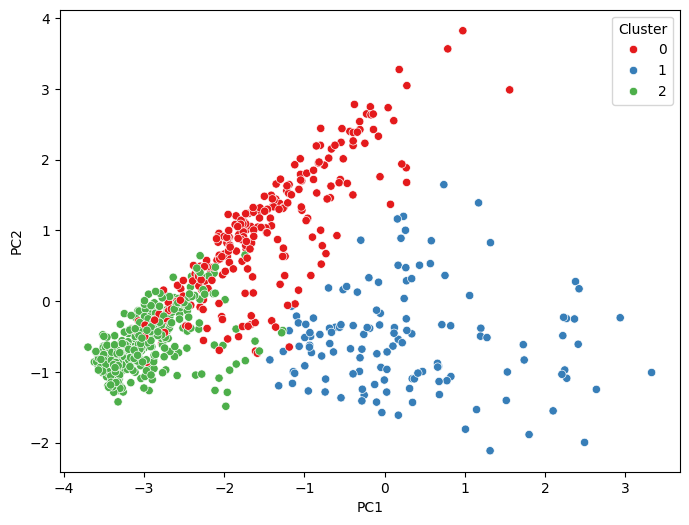

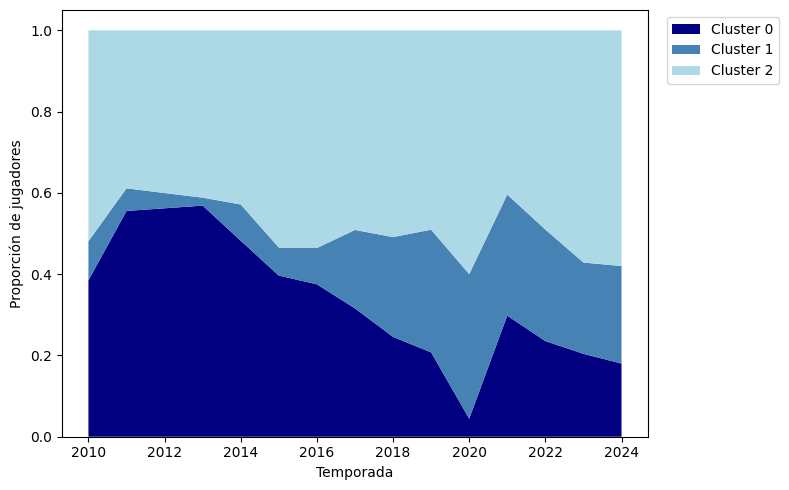


GRUPO: ALEROS
Silhouette Score (aleros): 0.2698

Medias ponderadas cluster:
                                   0         1         2
proporcion_aro                 0.191     0.165     0.318
proporcion_cerca               0.135     0.116     0.202
proporcion_media_distancia     0.316     0.131     0.108
proporcion_triple              0.146     0.432     0.115
proporcion_tiro_libre          0.212     0.156     0.258
altura                         2.048     2.028     2.044
peso                         233.878   224.822   234.590
season                      2015.213  2018.499  2017.836
acierto_aro                    0.674     0.667     0.691
acierto_cerca                  0.427     0.415     0.432
acierto_media_distancia        0.419     0.386     0.369
acierto_triple                 0.354     0.362     0.319
acierto_tiro_libre             0.795     0.772     0.705

tabla cluster por posicion:
Posicion     F   F-C   F-G
Cluster                   
0         51.9  29.4  18.7
1         73.7 

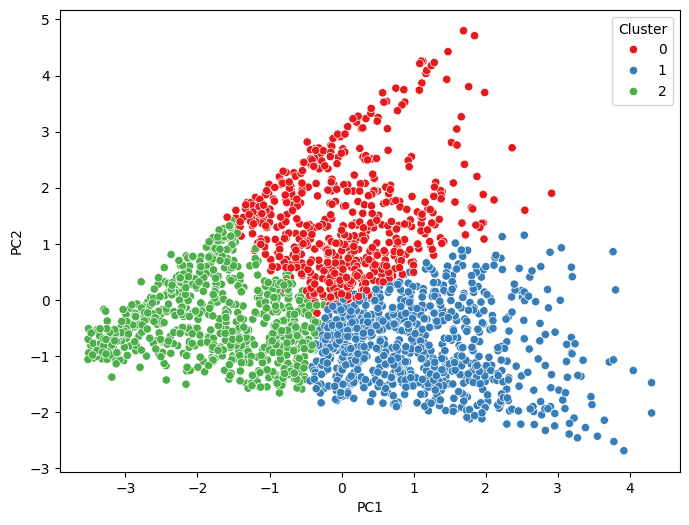

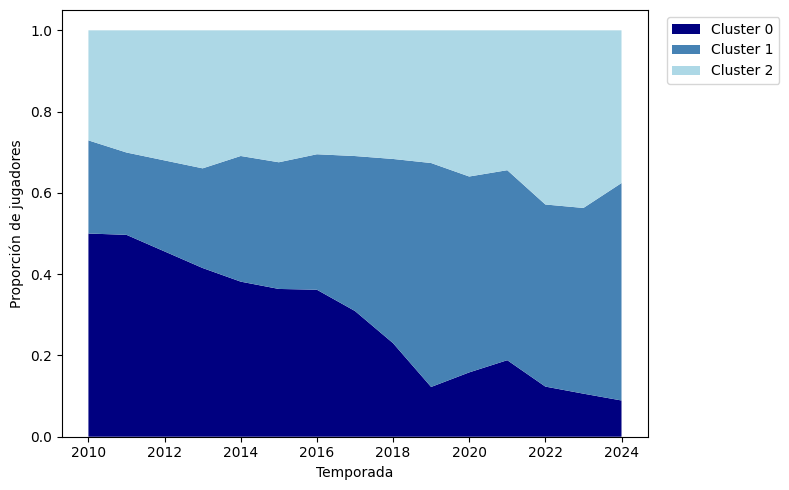

In [40]:
# vamos ahora a hacer los clusters por posiciones
dfs_grupos = {}

for nombre_grupo, posiciones in posiciones_grupos:
    df_grupo = datos_jugadores[datos_jugadores["Posicion"].isin(posiciones)].copy()

    escalador_grupo = StandardScaler()
    tiros_escalados = escalador_grupo.fit_transform(df_grupo[dist_tiros])
    modelo = KMeans(n_clusters=3, random_state=333, n_init=10)
    etiquetas_temporales = modelo.fit_predict(tiros_escalados)

    # voy a hacer que el cluster 0 sea siempre el de los que tiran media distancia y el 1 el de los triplitas, para ver si poco a poco se lo va comiendo.
    medias_media_distancia = []
    medias_triples = []
    for i in range(3):
        medias_media_distancia.append(df_grupo[etiquetas_temporales == i]["proporcion_media_distancia"].mean())
        medias_triples.append(df_grupo[etiquetas_temporales == i]["proporcion_triple"].mean())

    indice_media_distancia = medias_media_distancia.index(max(medias_media_distancia))

    indice_triples = -1
    max_triples = -1.0
    for i in range(3):
        if i != indice_media_distancia and medias_triples[i] > max_triples:
            max_triples = medias_triples[i]
            indice_triples = i

    indice_restante = -1
    for i in range(3):
        if i != indice_media_distancia and i != indice_triples:
            indice_restante = i

    mapa_etiquetas = {indice_media_distancia: 0, indice_triples: 1, indice_restante: 2}
    df_grupo["Cluster"] = [mapa_etiquetas[valor] for valor in etiquetas_temporales]


    dfs_grupos[nombre_grupo] = df_grupo

    puntuacion_silueta = silhouette_score(tiros_escalados, df_grupo["Cluster"])
    print(f"\nGRUPO: {nombre_grupo.upper()}")
    print(f"Silhouette Score ({nombre_grupo}): {round(puntuacion_silueta, 4)}")

    resumen_resultados = []

    for i in range(3):
        df_i = df_grupo[df_grupo["Cluster"] == i]
        a = {}
        for col in medias:
            a[col] = df_i[col].mean()

        for tiro in tipos_tiro:
            intentos = df_i[f"intentos_{tiro}"].sum()
            a[f"acierto_{tiro}"] = (df_i[f"acierto_{tiro}"] * df_i[f"intentos_{tiro}"]).sum() / intentos if intentos > 0 else 0

        resumen_resultados.append(a)

    resumen_clusters = pd.DataFrame(resumen_resultados)

    print("\nMedias ponderadas cluster:")
    print(resumen_clusters.T.round(3))

    distribucion_cluster = pd.crosstab(df_grupo["Cluster"], df_grupo["Posicion"], normalize="index") * 100
    print("\ntabla cluster por posicion:")
    print(distribucion_cluster.round(1))

    distribucion_posiciones = pd.crosstab(df_grupo["Cluster"], df_grupo["Posicion"], normalize="columns") * 100
    print("\n tabla posicion por cluster:")
    print(distribucion_posiciones.round(1))

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_grupo, x="PC1", y="PC2", hue="Cluster", palette="Set1")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    grafico_evolucion = pd.crosstab(df_grupo["season"], df_grupo["Cluster"], normalize="index")
    grafico_evolucion = grafico_evolucion.reindex(columns=[0, 1, 2], fill_value=0.0)
    colores = ["navy", "steelblue", "lightblue"]

    plt.figure(figsize=(8, 5))
    plt.stackplot(grafico_evolucion.index, [grafico_evolucion[i] for i in range(3)], labels=[f"Cluster {i}" for i in range(3)], colors=colores)
    plt.xlabel("Temporada")
    plt.ylabel("Proporción de jugadores")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

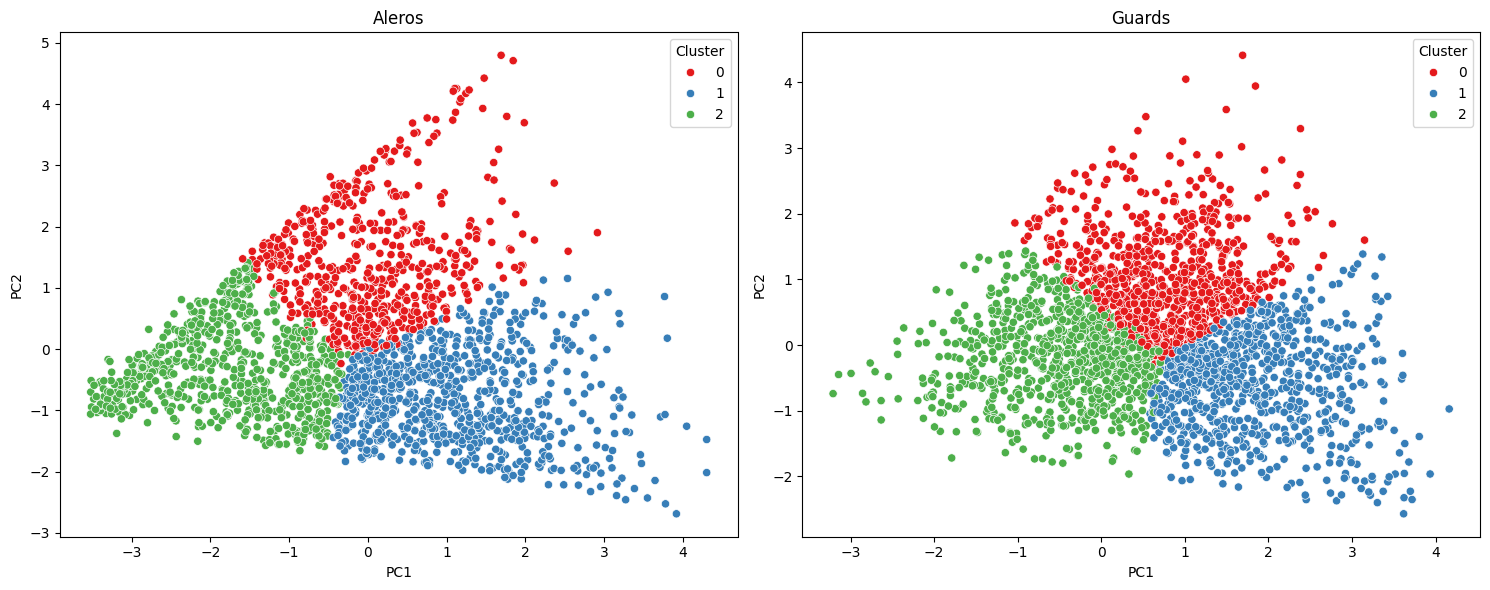

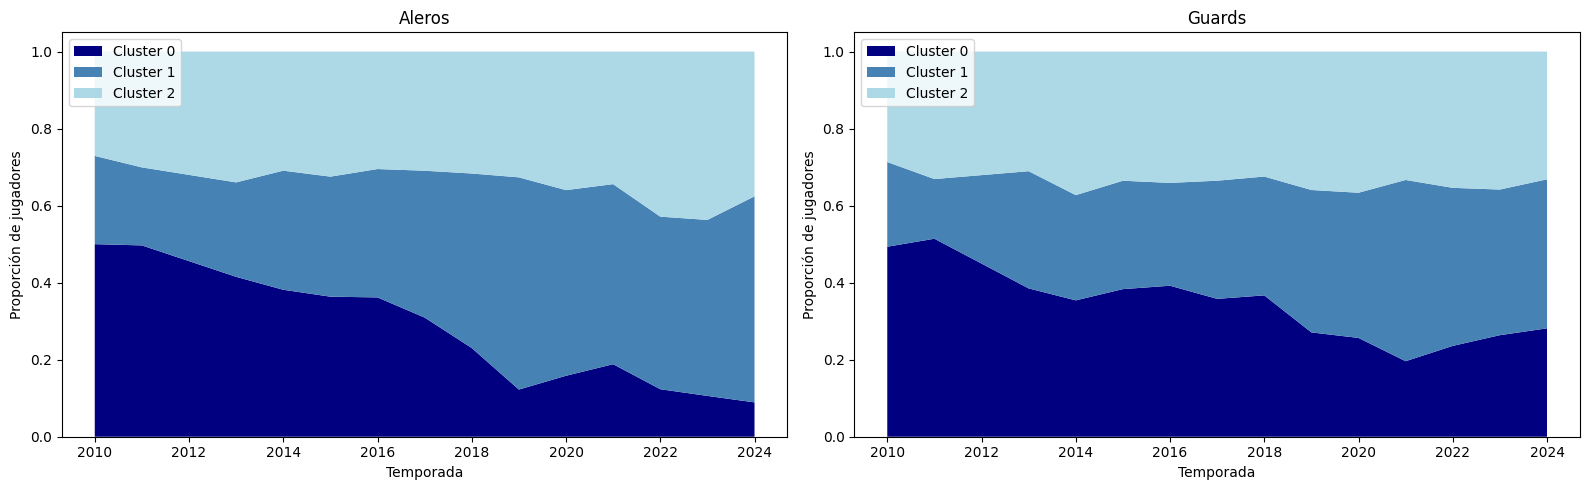

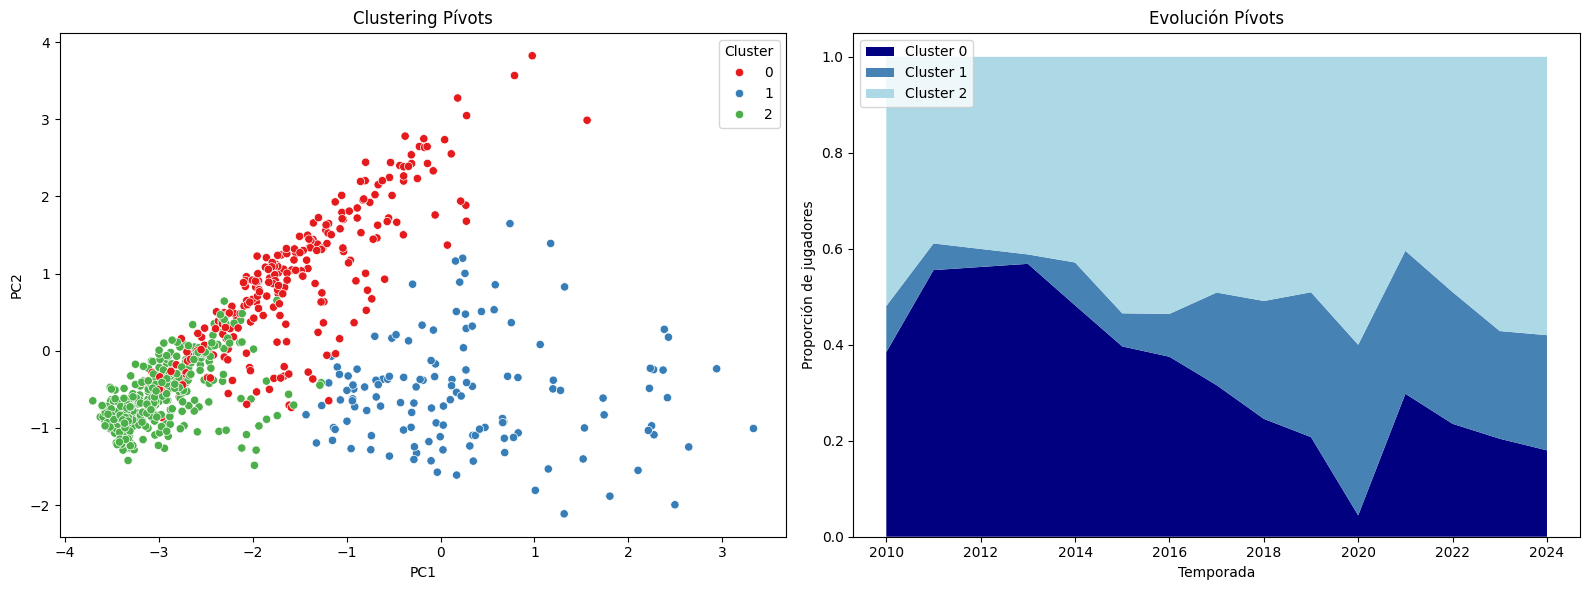

In [41]:
# para dejarlo como esta en el tfg añado este codigo agrupando guards y aleros.
dfs_grupos = {}
for nombre_grupo, posiciones in posiciones_grupos:
    df_grupo = datos_jugadores[datos_jugadores["Posicion"].isin(posiciones)].copy()
    tiros_escalados = StandardScaler().fit_transform(df_grupo[dist_tiros])
    modelo = KMeans(n_clusters=3, random_state=333, n_init=10)
    etiquetas_temporales = modelo.fit_predict(tiros_escalados)
    medias_media_distancia = [df_grupo[etiquetas_temporales == i]["proporcion_media_distancia"].mean() for i in range(3)]
    medias_triples = [df_grupo[etiquetas_temporales == i]["proporcion_triple"].mean() for i in range(3)]

    idx_dist = medias_media_distancia.index(max(medias_media_distancia))
    idx_trip = np.argsort(medias_triples)[-1] if np.argsort(medias_triples)[-1] != idx_dist else np.argsort(medias_triples)[-2]
    idx_rest = 3 - idx_dist - idx_trip
    mapa_etiquetas = {idx_dist: 0, idx_trip: 1, idx_rest: 2}
    df_grupo["Cluster"] = [mapa_etiquetas[valor] for valor in etiquetas_temporales]
    dfs_grupos[nombre_grupo] = df_grupo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=dfs_grupos["aleros"], x="PC1", y="PC2", hue="Cluster", palette="Set1", ax=ax1)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("Aleros")

sns.scatterplot(data=dfs_grupos["guards"], x="PC1", y="PC2", hue="Cluster", palette="Set1", ax=ax2)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title("Guards")

plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

graf_evol_aleros = pd.crosstab(dfs_grupos["aleros"]["season"], dfs_grupos["aleros"]["Cluster"], normalize="index").reindex(columns=[0, 1, 2], fill_value=0.0)
ax1.stackplot(graf_evol_aleros.index, [graf_evol_aleros[i] for i in range(3)], labels=[f"Cluster {i}" for i in range(3)], colors=["navy", "steelblue", "lightblue"])
ax1.set_xlabel("Temporada")
ax1.set_ylabel("Proporción de jugadores")
ax1.set_title("Aleros")
ax1.legend(loc="upper left")

graf_evol_guards = pd.crosstab(dfs_grupos["guards"]["season"], dfs_grupos["guards"]["Cluster"], normalize="index").reindex(columns=[0, 1, 2], fill_value=0.0)
ax2.stackplot(graf_evol_guards.index, [graf_evol_guards[i] for i in range(3)], labels=[f"Cluster {i}" for i in range(3)], colors=["navy", "steelblue", "lightblue"])
ax2.set_xlabel("Temporada")
ax2.set_ylabel("Proporción de jugadores")
ax2.set_title("Guards")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=dfs_grupos["centers"], x="PC1", y="PC2", hue="Cluster", palette="Set1", ax=ax1)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("Clustering Pívots")

graf_evol_centers = pd.crosstab(dfs_grupos["centers"]["season"], dfs_grupos["centers"]["Cluster"], normalize="index").reindex(columns=[0, 1, 2], fill_value=0.0)
ax2.stackplot(graf_evol_centers.index, [graf_evol_centers[i] for i in range(3)], labels=[f"Cluster {i}" for i in range(3)], colors=["navy", "steelblue", "lightblue"])
ax2.set_xlabel("Temporada")
ax2.set_ylabel("Proporción de jugadores")
ax2.set_title("Evolución Pívots")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

Una vez se ha visto que ha habido evolución, se va a comprobar si existe un punto de inflexión que hizo que hubiera un cambio brusco o si ha sido más o menos linear.


                    Breakpoint Regression Results                     
No. Observations                       14
No. Model Parameters                    4
Degrees of Freedom                     10
Res. Sum of Squares           0.000659765
Total Sum of Squares            0.0343836
R Squared                        0.980812
Adjusted R Squared               0.972283
Converged:                           True
                    Estimate      Std Err            t        P>|t|       [0.025       0.975]
----------------------------------------------------------------------------------------------------
const               -26.5039         1.61      -16.504      1.39e-08      -30.082      -22.926
alpha1             0.0132672     0.000797        16.65      1.28e-08     0.011492     0.015043
beta1             -0.0158576      0.00365      -4.3406             -    -0.023998   -0.0077175
breakpoint1          2021.21        0.511            -             -       2020.1       2022.3
-----------------

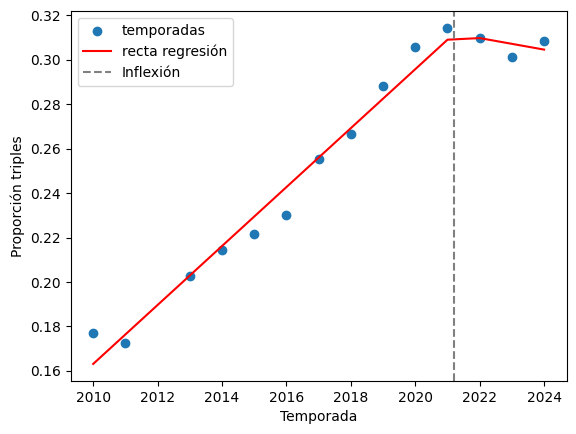

In [42]:
#regresion segmentada para la variable triples
datos_trip =datos_jugadores.groupby("season")["proporcion_triple"].mean().reset_index()
x_trip =datos_trip["season"].values
y_trip =datos_trip["proporcion_triple"].values

reg_trip =piecewise_regression.Fit(x_trip, y_trip, n_breakpoints=1)
reg_trip.summary()

resultados_trip =reg_trip.get_results()
punto_infl_trip =resultados_trip["estimates"]["breakpoint1"]["estimate"]
año_infl_trip =punto_infl_trip
y_pred_trip =reg_trip.predict(x_trip)

plt.scatter(x_trip, y_trip, label="temporadas")
plt.plot(x_trip, y_pred_trip, color="red", label="recta regresión")
plt.axvline(punto_infl_trip, color="gray", linestyle="--", label="Inflexión")
plt.xlabel("Temporada")
plt.ylabel("Proporción triples")
plt.legend()
plt.show()


                    Breakpoint Regression Results                     
No. Observations                       14
No. Model Parameters                    4
Degrees of Freedom                     10
Res. Sum of Squares           0.000400264
Total Sum of Squares            0.0231919
R Squared                        0.982741
Adjusted R Squared               0.975071
Converged:                           True
                    Estimate      Std Err            t        P>|t|       [0.025       0.975]
----------------------------------------------------------------------------------------------------
const                21.7011         1.27       17.029      1.03e-08       18.862       24.541
alpha1            -0.0106681     0.000632      -16.871      1.12e-08    -0.012077   -0.0092592
beta1             0.00764011       0.0029       2.6353             -    0.0011804       0.0141
breakpoint1           2020.7        0.941            -             -       2018.6       2022.8
-----------------

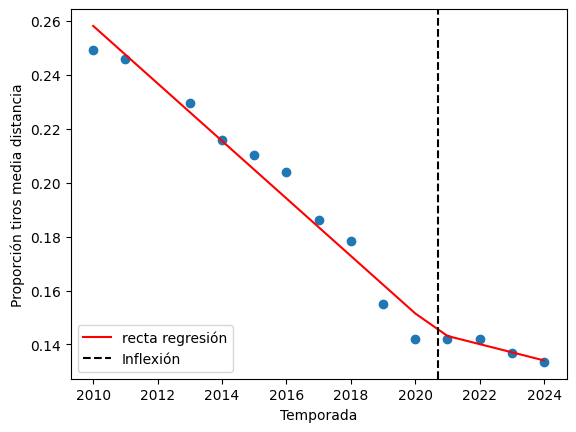

In [43]:
#mismo para tiros de media distancia
datos_dist =datos_jugadores.groupby("season")["proporcion_media_distancia"].mean().reset_index()
x_dist =datos_dist["season"].values
y_dist =datos_dist["proporcion_media_distancia"].values

reg_seg_dist =piecewise_regression.Fit(x_dist, y_dist, n_breakpoints=1)
reg_seg_dist.summary()

resultados_dist =reg_seg_dist.get_results()
punto_infl_dist =resultados_dist["estimates"]["breakpoint1"]["estimate"]
año_inflexion_dist =punto_infl_dist
y_pred_dist =reg_seg_dist.predict(x_dist)

plt.scatter(x_dist, y_dist,)
plt.plot(x_dist, y_pred_dist, color="red", label="recta regresión")
plt.axvline(punto_infl_dist, color="black", linestyle="--", label="Inflexión")
plt.xlabel("Temporada")
plt.ylabel("Proporción tiros media distancia")
plt.legend()
plt.show()

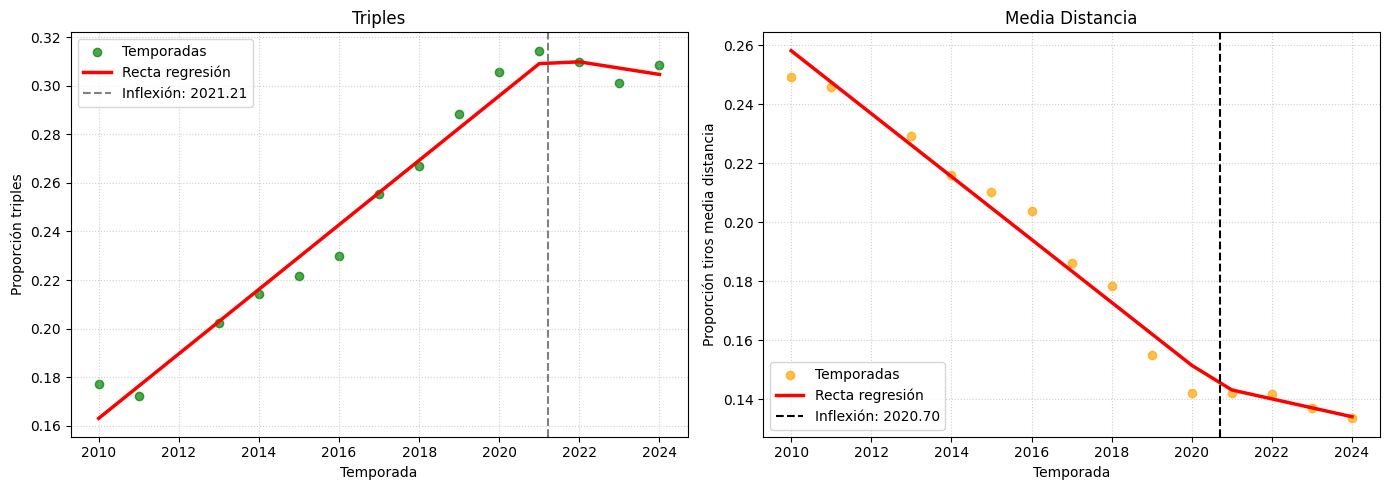

In [44]:
#para que queden en la misma figura lo hago aqui. Siempre que veas que se repite es por que lo he hecho a posteriori
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(x_trip, y_trip, color="green", alpha=0.7, label="Temporadas")
ax1.plot(x_trip, y_pred_trip, color="red", linewidth=2.5, label="Recta regresión")
ax1.axvline(punto_infl_trip, color="gray", linestyle="--", label=f"Inflexión: {punto_infl_trip:.2f}")
ax1.set_xlabel("Temporada")
ax1.set_ylabel("Proporción triples")
ax1.set_title("Triples")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

ax2.scatter(x_dist, y_dist, color="orange", alpha=0.7, label="Temporadas")
ax2.plot(x_dist, y_pred_dist, color="red", linewidth=2.5, label="Recta regresión")
ax2.axvline(punto_infl_dist, color="black", linestyle="--", label=f"Inflexión: {punto_infl_dist:.2f}")
ax2.set_xlabel("Temporada")
ax2.set_ylabel("Proporción tiros media distancia")
ax2.set_title("Media Distancia")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [45]:
#con esto calculaba la probabilidad de estar en el cluster 2 y marcar mas de 18 puntos pero al final acabe expresandolo de otra forma en la memoria
#si que es bastante util ver la lista de los jugadores con sus puntos
medias_mid ={}
for i in range(4):
    sub_df =datos_jugadores[datos_jugadores["Cluster"] ==i]
    media_val =sub_df["proporcion_media_distancia"].mean()
    medias_mid[i] =media_val

cluster_media_dist =0
max_media =-1.0
for k, v in medias_mid.items():
    if v > max_media:
        max_media =v
        cluster_media_dist =k

datos_2024 =datos_jugadores[datos_jugadores["season"] ==2024].copy()

datos_2024["tiro_2"] =(
    (datos_2024["acierto_aro"] * datos_2024["intentos_aro"]) +
    (datos_2024["acierto_cerca"] * datos_2024["intentos_cerca"]) +
    (datos_2024["acierto_media_distancia"] * datos_2024["intentos_media_distancia"])
)

datos_2024["puntos"] =(
    2 * datos_2024["tiro_2"] +
    3 * (datos_2024["acierto_triple"] * datos_2024["intentos_triple"]) +
    1 * (datos_2024["acierto_tiro_libre"] * datos_2024["intentos_tiro_libre"])
)

datos_2024["ppg"] =datos_2024["puntos"] / datos_2024["partidos_jugados"]

dentro =datos_2024[datos_2024["Cluster"] ==cluster_media_dist]
fuera =datos_2024[datos_2024["Cluster"] !=cluster_media_dist]

peloteros =len(dentro[dentro["ppg"] >=18])
resto =len(fuera[fuera["ppg"] >=18])

prob_dentro =peloteros/len(dentro)
prob_pelotero =peloteros/(peloteros + resto)

print("Probabilidad de marcar 18 puntos si está dentro del cluster:", round(prob_dentro, 4))
print("Probabilidad de estar dentro si marca 18 puntos:", round(prob_pelotero, 4))
print(f"\nHay {len(dentro)} jugadores que siguen tirando de media distancia, son:")

lista_peloteros =dentro.sort_values(by="ppg", ascending=False)
for idx, row in lista_peloteros.iterrows():
    print(f"{row["jugador"]}: {round(row["ppg"], 2)}")

Probabilidad de marcar 18 puntos si está dentro del cluster: 0.6222
Probabilidad de estar dentro si marca 18 puntos: 0.4828

Hay 45 jugadores que siguen tirando de media distancia, son:
Joel Embiid: 34.15
Shai Gilgeous-Alexander: 29.28
Jalen Brunson: 28.48
Kevin Durant: 26.82
Devin Booker: 26.58
De'Aaron Fox: 25.92
Donovan Mitchell: 25.7
Jayson Tatum: 25.69
Anthony Edwards: 25.17
Trae Young: 24.41
Kyrie Irving: 24.11
Damian Lillard: 23.99
DeMar DeRozan: 23.94
Kawhi Leonard: 22.82
Paolo Banchero: 22.45
Dejounte Murray: 22.42
Cam Thomas: 21.92
Anfernee Simons: 21.76
Paul George: 21.69
Jamal Murray: 20.42
Brandon Ingram: 20.24
Devin Vassell: 19.19
Tyrese Haliburton: 19.05
Bam Adebayo: 19.04
Jalen Green: 18.85
Terry Rozier: 18.84
Zach LaVine: 18.8
Jalen Williams: 18.64
Bradley Beal: 17.82
Jordan Poole: 16.87
Deandre Ayton: 16.73
James Harden: 15.79
Khris Middleton: 15.72
Malcolm Brogdon: 15.46
Bobby Portis: 13.95
Scoot Henderson: 13.73
Andrew Nembhard: 10.39
Gordon Hayward: 9.24
Chris Paul

In [46]:
#igual que antes pero para el 2010
datos_2010 =datos_jugadores[datos_jugadores["season"] ==2010].copy()

datos_2010["tiro_2"] =(
    (datos_2010["acierto_aro"] * datos_2010["intentos_aro"]) +
    (datos_2010["acierto_cerca"] * datos_2010["intentos_cerca"]) +
    (datos_2010["acierto_media_distancia"] * datos_2010["intentos_media_distancia"])
)

datos_2010["puntos"] =(
    2 * datos_2010["tiro_2"] +
    3 * (datos_2010["acierto_triple"] * datos_2010["intentos_triple"]) +
    1 * (datos_2010["acierto_tiro_libre"] * datos_2010["intentos_tiro_libre"])
)

datos_2010["ppg"] =datos_2010["puntos"] / datos_2010["partidos_jugados"]

dentro_2010 =datos_2010[datos_2010["Cluster"] ==cluster_media_dist]
fuera_2010 =datos_2010[datos_2010["Cluster"] !=cluster_media_dist]

peloteros_2010 =len(dentro_2010[dentro_2010["ppg"] >=18])
resto_2010 =len(fuera_2010[fuera_2010["ppg"] >=18])

prob_dentro_2010 =peloteros_2010/len(dentro_2010)
prob_si_18_2010 =peloteros_2010/(peloteros_2010 + resto_2010)

print("Probabilidad de marcar 18 puntos o mas dentro del cluster:", round(prob_dentro_2010, 4))
print("Probabilidad de estar dentro si marca 18 puntos:", round(prob_si_18_2010, 4))
print(f"\nHay {len(dentro_2010)} jugadores que siguen tirando de media distancia, son:")

lista_peloteros_2010 =dentro_2010.sort_values(by="ppg", ascending=False)
for idx, row in lista_peloteros_2010.iterrows():
    print(f"{row["jugador"]}: {round(row["ppg"], 2)}")

Probabilidad de marcar 18 puntos o mas dentro del cluster: 0.1453
Probabilidad de estar dentro si marca 18 puntos: 0.7353

Hay 172 jugadores que siguen tirando de media distancia, son:
Kevin Durant: 29.63
LeBron James: 29.45
Carmelo Anthony: 28.29
Kobe Bryant: 27.67
Dwyane Wade: 26.98
Monta Ellis: 25.48
Dirk Nowitzki: 25.1
Danny Granger: 24.15
Chris Bosh: 24.11
Gilbert Arenas: 22.56
Derrick Rose: 20.96
Brandon Roy: 20.79
Joe Johnson: 20.75
Kevin Martin: 20.57
Stephen Jackson: 20.46
David Lee: 20.05
Corey Maggette: 19.81
Chauncey Billups: 19.76
Rudy Gay: 19.59
Deron Williams: 19.26
David West: 19.02
Chris Paul: 18.69
Paul Pierce: 18.37
Chris Kaman: 18.33
Richard Hamilton: 18.07
LaMarcus Aldridge: 17.94
Tim Duncan: 17.84
Jamal Crawford: 17.82
Stephen Curry: 17.71
Luol Deng: 17.65
O.J. Mayo: 17.46
Andrea Bargnani: 17.27
Al Jefferson: 17.11
Andre Iguodala: 17.09
Devin Harris: 16.88
Rodney Stuckey: 16.64
Steve Nash: 16.57
Caron Butler: 16.52
Russell Westbrook: 16.42
Vince Carter: 16.42
Luis

In [47]:
#de aqui vi como los jugadores pertenecian a los 3 posibles bloques
media_liga_media_dist =datos_2024[datos_2024["intentos_media_distancia"] >= 50]["acierto_media_distancia"].mean()
print(f"\nMedia de acierto en media distancia de la liga en 2024: {round(media_liga_media_dist, 4)}")

liga_filtrada =datos_2024[datos_2024["intentos_media_distancia"] >= 20]

bajos =dentro[dentro["ppg"] < 18]
print(f"\nHay {len(bajos)} jugadores de media distancia con menos de 18 ppg, son:")
lista_bajos =bajos.sort_values(by="acierto_media_distancia", ascending=False)
for idx, row in lista_bajos.iterrows():
    percentil =(liga_filtrada["acierto_media_distancia"] < row["acierto_media_distancia"]).mean() * 100
    # Añadida la edad al print convirtiéndola a entero
    print(f"{row["jugador"]} (Edad: {int(row["edad"])}): Acierto = {round(row["acierto_media_distancia"], 4)} (Percentil = {round(percentil, 1)}%)")


Media de acierto en media distancia de la liga en 2024: 0.4033

Hay 17 jugadores de media distancia con menos de 18 ppg, son:
Khris Middleton (Edad: 32): Acierto = 0.5124 (Percentil = 95.4%)
Andrew Nembhard (Edad: 24): Acierto = 0.4847 (Percentil = 90.8%)
Deandre Ayton (Edad: 25): Acierto = 0.4802 (Percentil = 90.1%)
Bobby Portis (Edad: 28): Acierto = 0.4686 (Percentil = 84.5%)
Chris Paul (Edad: 38): Acierto = 0.4525 (Percentil = 79.9%)
Bradley Beal (Edad: 30): Acierto = 0.443 (Percentil = 74.6%)
Danilo Gallinari (Edad: 35): Acierto = 0.4167 (Percentil = 61.1%)
Killian Hayes (Edad: 22): Acierto = 0.4154 (Percentil = 60.4%)
Marcus Sasser (Edad: 23): Acierto = 0.4128 (Percentil = 58.7%)
James Harden (Edad: 34): Acierto = 0.4086 (Percentil = 54.1%)
Scoot Henderson (Edad: 19): Acierto = 0.3976 (Percentil = 47.5%)
Brandon Boston Jr. (Edad: 22): Acierto = 0.3913 (Percentil = 43.9%)
Malcolm Brogdon (Edad: 31): Acierto = 0.3767 (Percentil = 37.0%)
Gordon Hayward (Edad: 33): Acierto = 0.3712 (

Ahora se va a realizar la segunda parte, una validación cruzada que busca predecir los resultados de la fase de playoff en base a los de la temporada regular. Antes de empezar a realizar los modelos se realizará un EDA.


In [48]:
from sklearn.utils import shuffle
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from collections import Counter
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelBinarizer
import warnings
import statsmodels.api as sm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import IPython.display as display
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import shapiro
from scipy.stats import kruskal, rankdata, norm
import itertools
from statsmodels.miscmodels.ordinal_model import OrderedModel


/tmp/ipykernel_853/258697696.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


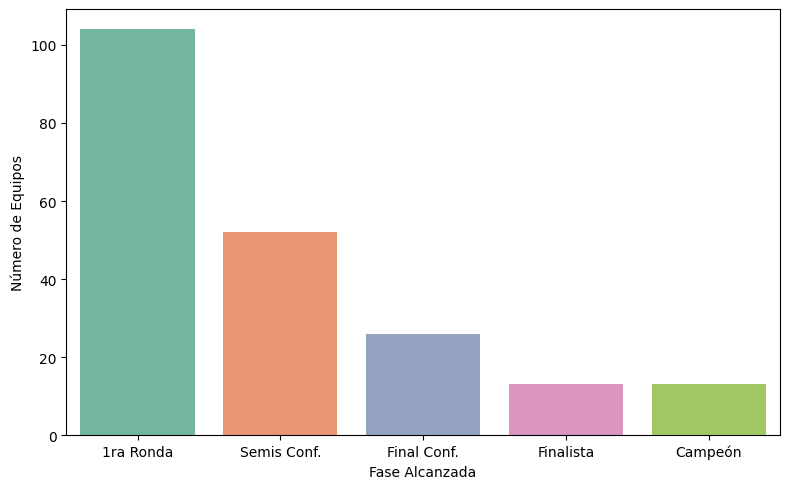

/tmp/ipykernel_853/258697696.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


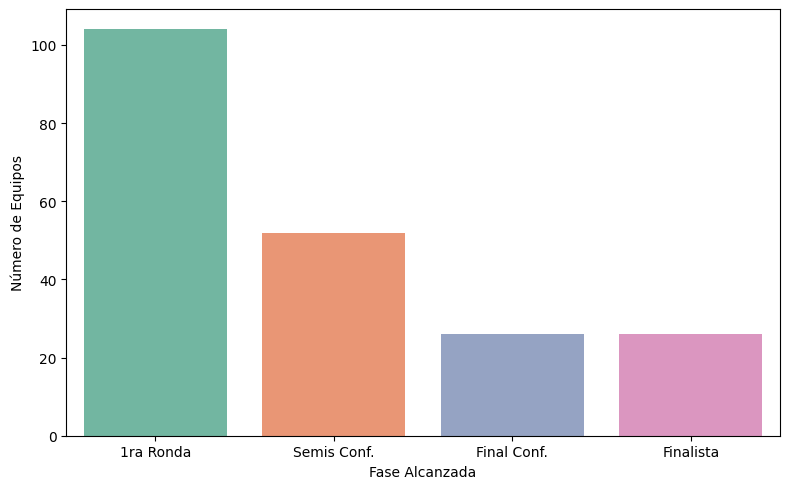

X:
     tiros_campo_anotados  tiros_campo_intentados  triples_anotados  \
162             43.138889               87.347222         14.166667   
61              40.560976               83.463415          8.512195   
166             40.625000               86.069444         11.055556   
122             40.841463               86.560976         10.987805   
41              37.085366               80.975610          8.719512   

     triples_intentados  tiros_libres_anotados  tiros_libres_intentados  \
162           36.111111              18.125000                22.541667   
61            21.426829              15.719512                20.024390   
166           31.222222              17.236111                23.319444   
122           29.817073              17.134146                22.780488   
41            24.573171              19.317073                27.914634   

     rebotes_ofensivos  rebotes_defensivos  rebotes_totales  asistencias  \
162           8.888889           35.541667 

In [49]:
#se va a realizar un EDA para explorar nuestros datos y decidir que variables mantener
datos_temporadas =pd.read_csv("datos_temporadas.csv")
datos_temporadas =shuffle(datos_temporadas, random_state =333)
descartes =["temporada", "equipo", "equipo", "fase_alcanzada","año_temporada"]

map_texto_1 ={
    0: "1ra Ronda",
    1: "Semis Conf.",
    2: "Final Conf.",
    3: "Finalista",
    4: "Campeón"
}
datos_temporadas["graf_1"] =datos_temporadas["fase_alcanzada"].map(map_texto_1)

plt.figure(figsize =(8, 5))
sns.countplot(
    data =datos_temporadas,
    x ="graf_1",
    palette ="Set2",
    order =["1ra Ronda", "Semis Conf.", "Final Conf.", "Finalista", "Campeón"]
)
plt.xlabel("Fase Alcanzada")
plt.ylabel("Número de Equipos")
plt.tight_layout()
plt.show()

#debido a que solo había 13 campeones y 13 finalistas he decidido fusionar estos dos casos.
#De esta forma tengo 104 equipos eliminados en primera ronda, 52 eliminados en segunda y 26 finalistas de conferencia y finalistas.
datos_temporadas["fase_alcanzada"] =datos_temporadas["fase_alcanzada"].replace(4, 3)
X =datos_temporadas.drop(columns =descartes)

map_texto_2 ={
    0: "1ra Ronda",
    1: "Semis Conf.",
    2: "Final Conf.",
    3: "Finalista"
}
datos_temporadas["graf_2"] =datos_temporadas["fase_alcanzada"].map(map_texto_2)

plt.figure(figsize =(8, 5))
sns.countplot(
    data =datos_temporadas,
    x ="graf_2",
    palette ="Set2",
    order =["1ra Ronda", "Semis Conf.", "Final Conf.", "Finalista"]
)
plt.xlabel("Fase Alcanzada")
plt.ylabel("Número de Equipos")
plt.tight_layout()
plt.show()
adios =["graf_1", "graf_2"]
X =X.drop(columns =adios, errors ="ignore")
y =datos_temporadas["fase_alcanzada"].values
print(f"X:\n{X.head()}")
print(f"y:\n{y[:5]}\n")


In [50]:
#voy a describir cada variable explicativa
numericas =X.select_dtypes(include =["float64", "int64"]).columns.tolist()
categoricas =X.select_dtypes(include =["object", "category"]).columns.tolist()
tabla_descriptiva =X[numericas].agg(["mean", "std", "min", "max", "skew", "kurtosis"]).T
print("Estadísticos descriptivos de las variables:")
print(tabla_descriptiva.round(3))
print("\n")



Estadísticos descriptivos de las variables:
                            mean    std     min      max   skew  kurtosis
tiros_campo_anotados      39.533  2.265  34.470   44.736  0.097    -0.783
tiros_campo_intentados    85.063  3.738  75.841   94.378 -0.053    -0.521
triples_anotados          10.035  2.828   3.768   16.736  0.043    -0.618
triples_intentados        27.567  7.494  11.293   45.378  0.056    -0.668
tiros_libres_anotados     17.742  1.718  13.470   24.110  0.649     0.727
tiros_libres_intentados   23.047  2.277  18.152   31.085  0.641     0.530
rebotes_ofensivos         10.363  1.274   7.646   14.134  0.377    -0.054
rebotes_defensivos        33.443  2.045  27.195   42.233  0.305     1.501
rebotes_totales           43.806  2.236  36.878   51.699  0.077     0.770
asistencias               23.457  2.329  18.500   30.378  0.342    -0.056
perdidas_balon            14.034  0.994  11.097   16.744  0.124     0.298
robos                      7.742  0.885   5.537   10.012  0.141    -

Correlaciones bivariadas respecto a fase_alcanzada:
                   Variable  Correlación
0                 victorias        0.557
1       acierto_tiros_campo        0.352
2           acierto_triples        0.270
3               asistencias        0.210
4                  bloqueos        0.176
5      acierto_tiros_libres        0.167
6        rebotes_defensivos        0.138
7                    puntos        0.123
8            perdidas_balon        0.115
9          triples_anotados        0.110
10     tiros_campo_anotados        0.107
11       triples_intentados        0.072
12                    robos        0.047
13    tiros_libres_anotados        0.032
14          rebotes_totales        0.010
15  tiros_libres_intentados       -0.042
16        faltas_personales       -0.087
17   tiros_campo_intentados       -0.112
18        rebotes_ofensivos       -0.203




/tmp/ipykernel_853/3877772530.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_853/3877772530.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_853/3877772530.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_853/3877772530.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_853/3877772530.py:28: FutureWarning: 

Passin

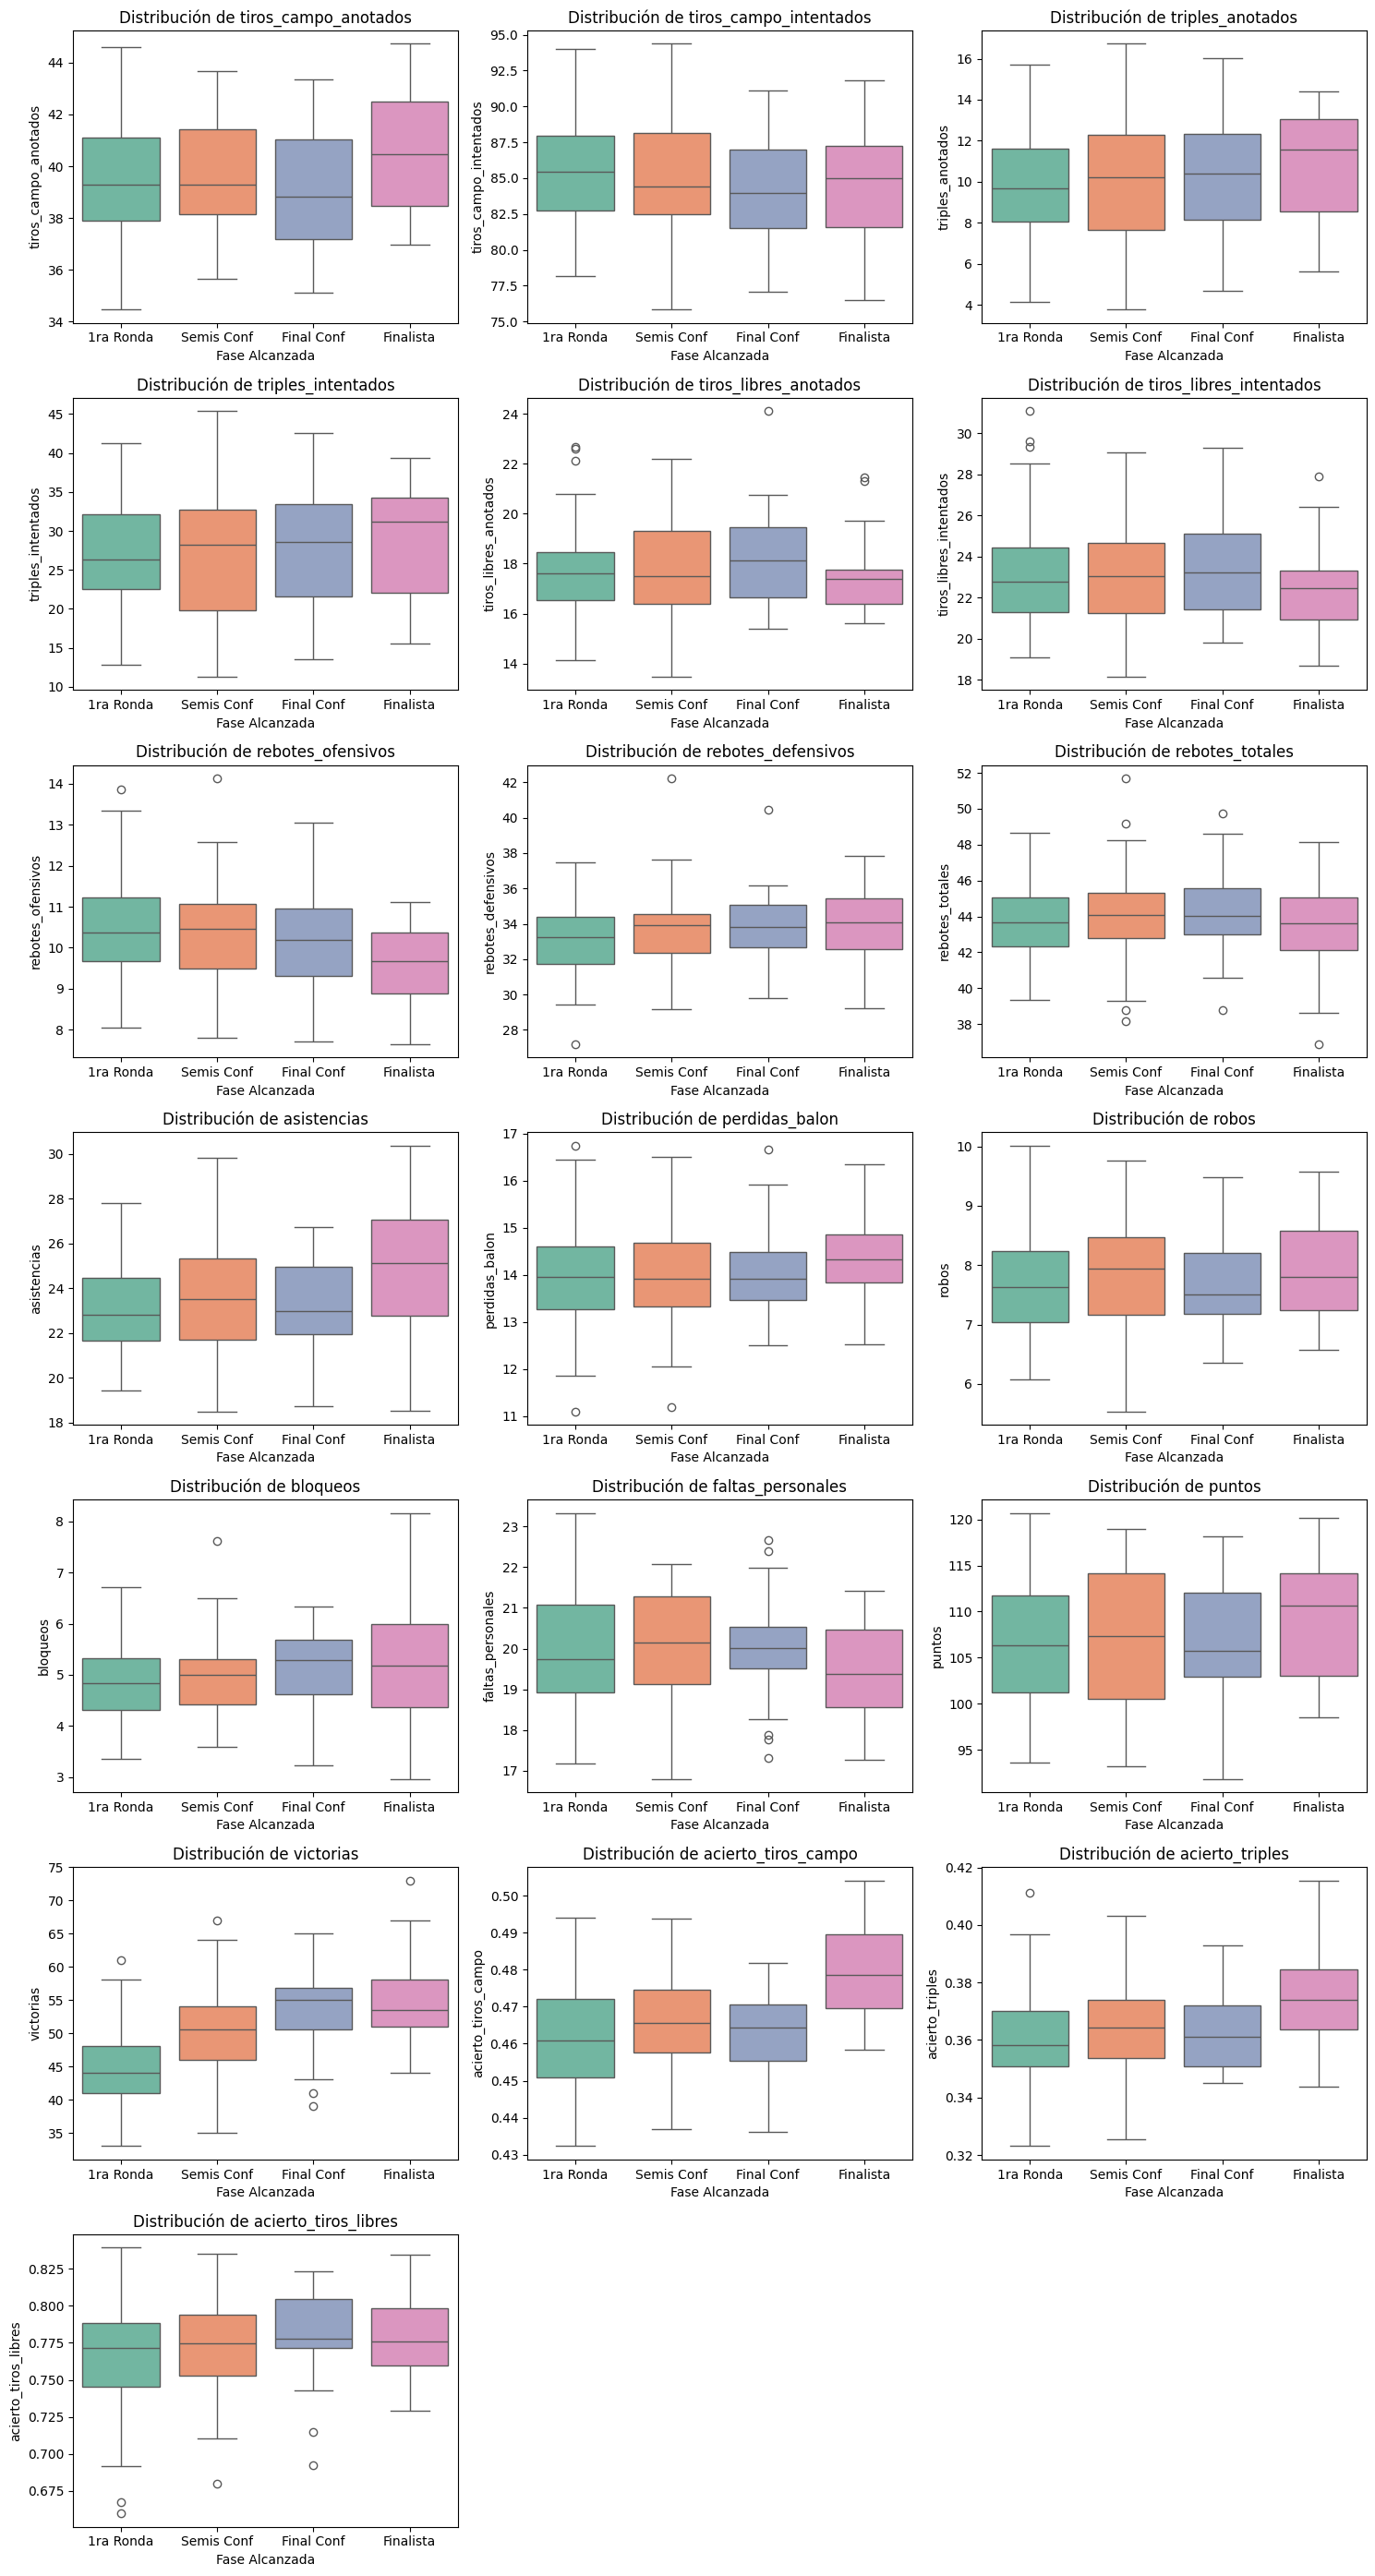


Variable: tiros_campo_anotados
  Grupo 0 p-valor: 0.6755087338527472
  Grupo 1 p-valor: 0.09352368945217222
  Grupo 2 p-valor: 0.48100148538917353
  Grupo 3 p-valor: 0.223274009198068

Variable: tiros_campo_intentados
  Grupo 0 p-valor: 0.4510738442093566
  Grupo 1 p-valor: 0.3952105555426636
  Grupo 2 p-valor: 0.4480892281340885
  Grupo 3 p-valor: 0.18492386759557677

Variable: triples_anotados
  Grupo 0 p-valor: 0.7363457224279107
  Grupo 1 p-valor: 0.3541103020937505
  Grupo 2 p-valor: 0.8348176072893709
  Grupo 3 p-valor: 0.08793717748760761

Variable: triples_intentados
  Grupo 0 p-valor: 0.3850441668290351
  Grupo 1 p-valor: 0.3170044851420327
  Grupo 2 p-valor: 0.5568748960319074
  Grupo 3 p-valor: 0.09656173719652261

Variable: tiros_libres_anotados
  Grupo 0 p-valor: 0.036420377538587304
  Grupo 1 p-valor: 0.31267243846078296
  Grupo 2 p-valor: 0.08287225133006057
  Grupo 3 p-valor: 0.007277106308591854

Variable: tiros_libres_intentados
  Grupo 0 p-valor: 0.00148660371554297

In [51]:
#miro la correlacion con la variable y primero y despues hago box plot para cada variable en funcion de las categorias de y
correlaciones_fase =X[numericas].corrwith(pd.Series(y, index =X.index))
tabla_correlaciones_fase =pd.DataFrame({
    "Variable": correlaciones_fase.index,
    "Correlación": correlaciones_fase.values
})
tabla_correlaciones_fase =tabla_correlaciones_fase.sort_values(by ="Correlación", ascending =False).reset_index(drop =True)
print("Correlaciones bivariadas respecto a fase_alcanzada:")
print(tabla_correlaciones_fase.round(3))
print("\n")

nombres_rondas ={
    0: "1ra Ronda",
    1: "Semis Conf",
    2: "Final Conf",
    3: "Finalista"
}
datos_box =X[numericas].copy()
datos_box["fase_alcanzada"] =pd.Series(y).map(nombres_rondas).values

n_vars =len(numericas)
n_cols =3
n_rows =(n_vars + n_cols - 1) // n_cols

fig, ejes =plt.subplots(n_rows, n_cols, figsize =(15, 4 * n_rows))
ejes =ejes.flatten()
for indice, variable in enumerate(numericas):
    sns.boxplot(
        data =datos_box,
        x ="fase_alcanzada",
        y =variable,
        ax =ejes[indice],
        palette ="Set2",
        order =["1ra Ronda", "Semis Conf", "Final Conf", "Finalista"]
    )
    ejes[indice].set_title(f"Distribución de {variable}")
    ejes[indice].set_xlabel("Fase Alcanzada")
    ejes[indice].set_ylabel(variable)

for i in range(n_vars, len(ejes)):
    fig.delaxes(ejes[i])

plt.tight_layout()
plt.show()

#compruebo normalidad

for columna in X.select_dtypes(include=['number']).columns:
    print(f"\nVariable: {columna}")
    for nombre_grupo, datos_grupo in X[columna].groupby(y):
        _, p_valor = shapiro(datos_grupo.dropna())
        print(f"  Grupo {nombre_grupo} p-valor: {p_valor}")



In [52]:
#aplico kruskall wallis al haber demasiadas variables que no sigan la distibución normal
#ahora hago un kruskal wallis
for variable in numericas:
    grupos =[X[variable][y ==clase].dropna() for clase in np.unique(y)]
    stat_kw, p_kw =kruskal(*grupos)
    print(f"Variable: {variable} - p-valor Kruskal-Wallis: {round(p_kw, 6)}")

Variable: tiros_campo_anotados - p-valor Kruskal-Wallis: 0.171212
Variable: tiros_campo_intentados - p-valor Kruskal-Wallis: 0.553601
Variable: triples_anotados - p-valor Kruskal-Wallis: 0.30533
Variable: triples_intentados - p-valor Kruskal-Wallis: 0.66385
Variable: tiros_libres_anotados - p-valor Kruskal-Wallis: 0.336943
Variable: tiros_libres_intentados - p-valor Kruskal-Wallis: 0.396339
Variable: rebotes_ofensivos - p-valor Kruskal-Wallis: 0.010919
Variable: rebotes_defensivos - p-valor Kruskal-Wallis: 0.198495
Variable: rebotes_totales - p-valor Kruskal-Wallis: 0.566998
Variable: asistencias - p-valor Kruskal-Wallis: 0.02219
Variable: perdidas_balon - p-valor Kruskal-Wallis: 0.215893
Variable: robos - p-valor Kruskal-Wallis: 0.582459
Variable: bloqueos - p-valor Kruskal-Wallis: 0.117688
Variable: faltas_personales - p-valor Kruskal-Wallis: 0.181196
Variable: puntos - p-valor Kruskal-Wallis: 0.265456
Variable: victorias - p-valor Kruskal-Wallis: 0.0
Variable: acierto_tiros_campo - 

VIF:


,Variable,VIF
0,tiros_campo_intentados,10.0621
1,rebotes_defensivos,4.9480
2,rebotes_ofensivos,3.5811
3,triples_intentados,3.3967
4,asistencias,3.1978
5,acierto_tiros_campo,2.8742
6,perdidas_balon,2.3462
7,victorias,2.0636
8,robos,1.9869
9,tiros_libres_intentados,1.8645


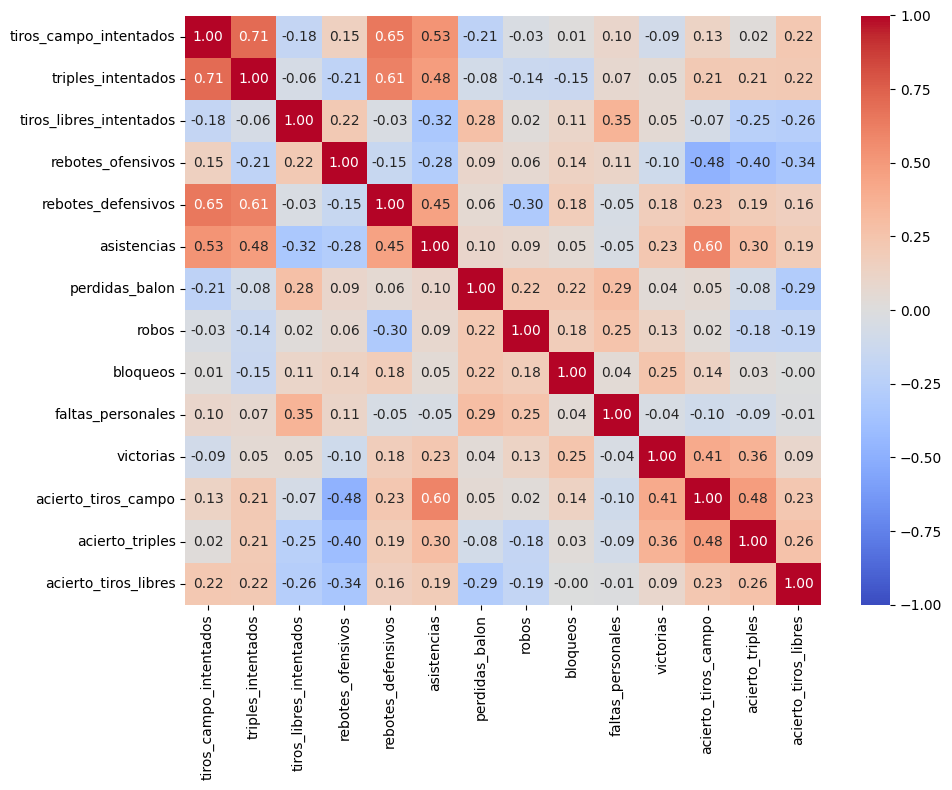

In [53]:
import IPython.display as display
#todas estas variables se han eliminado al poder obtenerse directamente por otras
descartes =["puntos", "tiros_campo_anotados", "triples_anotados", "tiros_libres_anotados", "rebotes_totales"]
X =X.drop(columns =descartes, errors ="ignore")
numericas =X.select_dtypes(include =["float64", "int64"]).columns.tolist()

datos_vif =add_constant(X[numericas])
datos_vif =datos_vif.fillna(datos_vif.median())
vif_valores =[]
nombres_col =X[numericas].columns
for indice in range(len(nombres_col)):
    valor_vif =variance_inflation_factor(datos_vif.values, indice +1)
    vif_valores.append({"Variable": nombres_col[indice], "VIF": round(valor_vif, 4)})

tabla_vif = pd.DataFrame(vif_valores)
tabla_vif = tabla_vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print("VIF:")
display.display(tabla_vif)

matriz_correlacion =X[numericas].corr()
plt.figure(figsize =(10, 8))
sns.heatmap(matriz_correlacion, annot =True, cmap ="coolwarm", fmt =".2f", vmin =-1, vmax =1)
plt.tight_layout()
plt.show()

In [54]:
#empezare escalando los datos
scaler =StandardScaler()
X_scaled =pd.DataFrame(scaler.fit_transform(X[numericas]), columns =numericas)
X_scaled_const =sm.add_constant(X_scaled)

# como primer analisis multivariante se hara una regresion logistica multinomial

regre =sm.MNLogit(y, X_scaled_const)
reg_resultados =regre.fit(disp =0)
resultados =reg_resultados.llf

#Ahora hacemos un LDA para no depender solo de la regresión

lda =LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)
LD =np.max(np.abs(lda.scalings_), axis =1)

print("Proporción de varianza explicada por cada componente discriminante del LDA:")
print(np.round(lda.explained_variance_ratio_, 3))
print("\n")

lda_coef =pd.DataFrame(lda.scalings_,
                        index=numericas,
                        columns=[f"LD{i+1}" for i in range(lda.scalings_.shape[1])])

print("Coeficientes ESTANDARIZADOS de las funciones discriminantes (LDA):")
print(lda_coef.round(3))
print("\n")

Proporción de varianza explicada por cada componente discriminante del LDA:
[0.782 0.178 0.039]


Coeficientes ESTANDARIZADOS de las funciones discriminantes (LDA):
                           LD1    LD2    LD3
tiros_campo_intentados  -0.971  0.553 -1.478
triples_intentados       0.439  0.036  0.016
tiros_libres_intentados -0.201 -0.120 -0.256
rebotes_ofensivos        0.266 -0.256  1.165
rebotes_defensivos       0.412 -0.610  1.175
asistencias              0.131 -0.148  0.485
perdidas_balon           0.026  0.478 -1.078
robos                    0.133  0.065  0.608
bloqueos                 0.066  0.025 -0.250
faltas_personales        0.004 -0.459  0.698
victorias                0.848 -0.429 -0.599
acierto_tiros_campo      0.265  0.728  0.767
acierto_triples         -0.104  0.292  0.162
acierto_tiros_libres     0.335 -0.256 -0.030




In [55]:
# Voy a hacer una tabla con los valores del analisis multivariado para ver que variables se pueden eliminar
#en el caso de la regresión trabajo con su razon de verosimilitud.

filas =[]
df_lrt =len(np.unique(y)) - 1
for idx, var in enumerate(numericas):
    try:
        X_reducido =X_scaled_const.drop(columns =[var])
        modelo_reducido =sm.MNLogit(y, X_reducido)
        resultados_reducido =modelo_reducido.fit(disp =0)
        llf_reducido =resultados_reducido.llf
        estadistico_lrt =2 * (resultados - llf_reducido)
        p_val_reg =stats.chi2.sf(estadistico_lrt, df =df_lrt)
    except Exception:
        p_val_reg =np.nan
    filas.append({
        "Variable": var,
        "p-valor Regresión": p_val_reg,
        "mayor valor absoluto LDA ": LD[idx]
    })
tabla_resumen =pd.DataFrame(filas)
tabla_resumen =tabla_resumen.sort_values(by ="p-valor Regresión").reset_index(drop =True)
display.display(tabla_resumen.round(4))

,Variable,p-valor Regresión,mayor valor absoluto LDA
0,victorias,0.0000,0.8482
1,acierto_tiros_campo,0.0108,0.7667
2,tiros_campo_intentados,0.0429,1.4783
3,perdidas_balon,0.0734,1.0785
4,acierto_tiros_libres,0.0759,0.3346
5,rebotes_defensivos,0.1279,1.1755
6,faltas_personales,0.1561,0.6984
7,triples_intentados,0.2015,0.4394
8,rebotes_ofensivos,0.2941,1.1647
9,robos,0.4485,0.6076


In [56]:
#eliminamos las variables que no sean significativas en ningun caso o que tengan valores pesimos del p valor en la regresión
descartes_2 =["bloqueos", "acierto_triples", "tiros_libres_intentados"]
X =X.drop(columns =descartes_2, errors ="ignore")

In [57]:
#he recalculado el VIF tras eliminar esas variables y ahora da por debajo de 10.
numericas =X.select_dtypes(include =["float64", "int64"]).columns.tolist()
datos_vif =add_constant(X[numericas])
datos_vif =datos_vif.fillna(datos_vif.median())
vif_valores =[]
nombres_col =X[numericas].columns
for indice in range(len(nombres_col)):
    valor_vif =variance_inflation_factor(datos_vif.values, indice +1)
    vif_valores.append({"Variable": nombres_col[indice], "VIF": round(valor_vif, 4)})

tabla_vif = pd.DataFrame(vif_valores)
tabla_vif = tabla_vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print("VIF:")
display.display(tabla_vif)

VIF:


,Variable,VIF
0,tiros_campo_intentados,9.4834
1,rebotes_defensivos,4.3307
2,rebotes_ofensivos,3.2166
3,triples_intentados,3.0109
4,asistencias,2.8634
5,perdidas_balon,2.3323
6,acierto_tiros_campo,2.3194
7,victorias,1.9753
8,robos,1.8079
9,acierto_tiros_libres,1.4386


Coeficientes de las regresiones logísticas binarias:
                         Y > 0   Y > 1   Y > 2
tiros_campo_intentados -1.4491 -0.6455 -0.7186
triples_intentados      0.3676  0.5199  0.8455
rebotes_ofensivos       0.5790  0.0238  0.0857
rebotes_defensivos      0.8213  0.0701 -0.0859
asistencias             0.4095  0.0069 -0.0493
perdidas_balon         -0.2358  0.4969  0.8389
robos                   0.3667 -0.0207  0.1853
faltas_personales       0.1383 -0.2983 -0.7286
victorias               1.2345  1.2742  0.7840
acierto_tiros_campo     0.2351  0.1485  1.3104
acierto_tiros_libres    0.5824  0.5155  0.3532
conferencia_Oeste      -0.3208 -0.2603 -0.4677




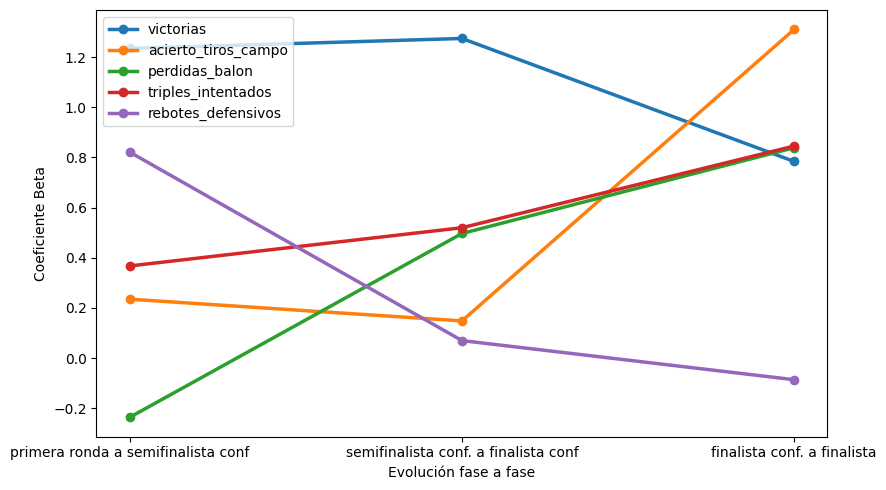

In [58]:
#voy a ver primero si esta variable cumple
# # codifico la conferencia y escalo todas las variables para hacer el test de paralelismo
X_comp =pd.get_dummies(X, drop_first =True)
columnas_modelo =X_comp.columns.tolist()
escalador =StandardScaler()
X_escalado =pd.DataFrame(escalador.fit_transform(X_comp), columns =columnas_modelo)
X_escalado_2 =sm.add_constant(X_escalado)


# Se crean los puntos de corte y estimo las regresiones logisticas binarias en cada punto de corte.
betas =[]
for k in range(3):
    cortes =(y > k).astype(int)
    modelo_binario =sm.Logit(cortes, X_escalado_2)
    resultados_binario =modelo_binario.fit(disp =0)
    betas.append(resultados_binario.params[1:]) # omito la constante
betas =np.array(betas)

# muestro los coeficientes de cada transicion en una tabla explicativa
tabla_coeficientes =pd.DataFrame(betas.T, index =columnas_modelo, columns =["Y > 0", "Y > 1", "Y > 2"])
print("Coeficientes de las regresiones logísticas binarias:")
print(tabla_coeficientes.round(4))
print("\n")

#ploteo, para representar mejor como de variables son los valores de Beta
variables_grafico =["victorias", "acierto_tiros_campo", "perdidas_balon", "triples_intentados", "rebotes_defensivos"]
plt.figure(figsize =(9, 5))
for var in variables_grafico:
    if var in columnas_modelo:
        indice =columnas_modelo.index(var)
        plt.plot(["primera ronda a semifinalista conf", "semifinalista conf. a finalista conf", "finalista conf. a finalista"], betas[:, indice], marker ='o', label =var, linewidth =2.5)

plt.xlabel("Evolución fase a fase")
plt.ylabel("Coeficiente Beta")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
# aplico lrt para estudiar si merece la pena considerarla categorica

# ajusto el modelo logit ordenado y el multinomial con metodos de optimizacion estables
ordinal_modelo =OrderedModel(y, X_escalado, distr ='logit')
ordinal_resultados =ordinal_modelo.fit(method ='powell', disp =0)# he tenido que utilizar powell por que si no, no se obtenia un p valor.

categor =sm.MNLogit(y, X_escalado_2)
res_categor =categor.fit(method ='bfgs', disp =0)

# calculo el estadistico y el p-valor usando size para que los grados de libertad sean correctos
estadistico_lrt =max(0.0, 2 * (res_categor.llf - ordinal_resultados.llf))
df_lrt =res_categor.params.size - ordinal_resultados.params.size
p_valor_lrt =stats.chi2.sf(estadistico_lrt, df =df_lrt)

print(f"LRT: {estadistico_lrt:.4f} | Grados de Libertad: {df_lrt}")
print(f"p-valor: {p_valor_lrt:.6e}")

LRT: 38.3341 | Grados de Libertad: 24
p-valor: 3.203539e-02


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [60]:
# vuelvo a definir los tipos de variables y uso el codigo dado por mi tutor alterando los hiperparemetros para definir los modelos
#he añadido tambien adaboost y Naive Bayes
numericas =X.select_dtypes(include =["float64", "int64"]).columns.tolist()
categoricas =X.select_dtypes(include =["object", "category"]).columns.tolist()


num_transformer =Pipeline([
    ("imputer", SimpleImputer(strategy ="median")),
    ("scaler", StandardScaler())
])
cat_transformer =OneHotEncoder(handle_unknown ="ignore", drop ="first")
preprocessor =ColumnTransformer([
    ("num", num_transformer, numericas),
    ("cat", cat_transformer, categoricas)
])
outer_cv =StratifiedKFold(n_splits =5, shuffle =True, random_state =333)
inner_cv =StratifiedKFold(n_splits =3, shuffle =True, random_state =333)
dist_fases ={0: 1.0, 1: 2.0, 2: 4.0, 3: 4.0}
models ={
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("preprocessing", preprocessor),
            ("model", LogisticRegression(max_iter=1000, class_weight=dist_fases, random_state=333))
        ]),
        "param_distributions": {
            "model__C": [ 0.1, 1.0, 10],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs"]
        }
    },

    "Decision Tree": {
        "pipeline": Pipeline([
            ("preprocessing", preprocessor),
            ("model", DecisionTreeClassifier(class_weight=dist_fases, random_state=33))
        ]),
        "param_distributions": {
            "model__max_depth": [3, 5, 7],
            "model__min_samples_split": [3,6],
            "model__criterion": ["gini", "entropy"]
        }
    },

    "K-Nearest Neighbors": {
        "pipeline": Pipeline([
            ("preprocessing", preprocessor),
            ("model", KNeighborsClassifier())
        ]),
        "param_distributions": {
            "model__n_neighbors": [ 5, 8, 11],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"]
        }
    },

    "SVC (SVM)": {
        "pipeline": Pipeline([
            ("preprocessing", preprocessor),
            ("model", SVC(probability=True, class_weight=dist_fases, random_state=333))
        ]),
        "param_distributions": [
            {
                "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
                "model__kernel": ["linear"]
            },
            {
                "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
                "model__kernel": ["rbf"],
                "model__gamma": ["scale", "auto"]
            }
        ]
    },

    "Random Forest": {
        "pipeline": Pipeline([
            ("preprocessing", preprocessor),
            ("model", RandomForestClassifier(class_weight=dist_fases, random_state=333))
        ]),
        "param_distributions": {
            "model__n_estimators": [50, 100],
            "model__max_depth": [3, 5],
            "model__min_samples_split": [5, 10],
            "model__min_samples_leaf": [2, 4],
            "model__max_features": ["sqrt"],
            "model__bootstrap": [True]
        }
    },

    "XGBoost": {
        "pipeline": Pipeline([
            ("preprocessing", preprocessor),
            ("model", XGBClassifier(eval_metric="logloss", random_state=333))
        ]),
        "param_distributions": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.5, 0.1],
            "model__subsample": [0.8],
            "model__colsample_bytree": [0.8, 1.0],
            "model__gamma": [0, 0.1],
            "model__reg_lambda": [1, 10]
        }
    },

    "LightGBM": {
        "pipeline": Pipeline([
            ("preprocessing", preprocessor),
            ("model", LGBMClassifier(class_weight=dist_fases, verbose=-1, random_state=333))
        ]),
        "param_distributions": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5],
            "model__num_leaves": [10],
            "model__min_child_samples": [5, 10],
            "model__subsample": [0.8],
            "model__colsample_bytree": [0.8, 1.0],
            "model__reg_lambda": [1, 10]
        }
    },

    "Naive Bayes": {
        "pipeline": Pipeline([
            ("preprocessing", preprocessor),
            ("model", GaussianNB(priors=[0.25, 0.25, 0.25, 0.25]))
        ]),
        "param_distributions": {
            "model__var_smoothing": [1e-9, 1e-8, 1e-7]
        }
    },

    "AdaBoost": {
        "pipeline": Pipeline([
            ("preprocessing", preprocessor),
            ("model", AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight=dist_fases), random_state=333))
        ]),
        "param_distributions": {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.05, 0.1, 1.0],
            "model__estimator__max_depth": [1, 2]
        }
    }
}

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
9 fits failed out of a total of 54.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits


...

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Resultados finales (Nested CV):


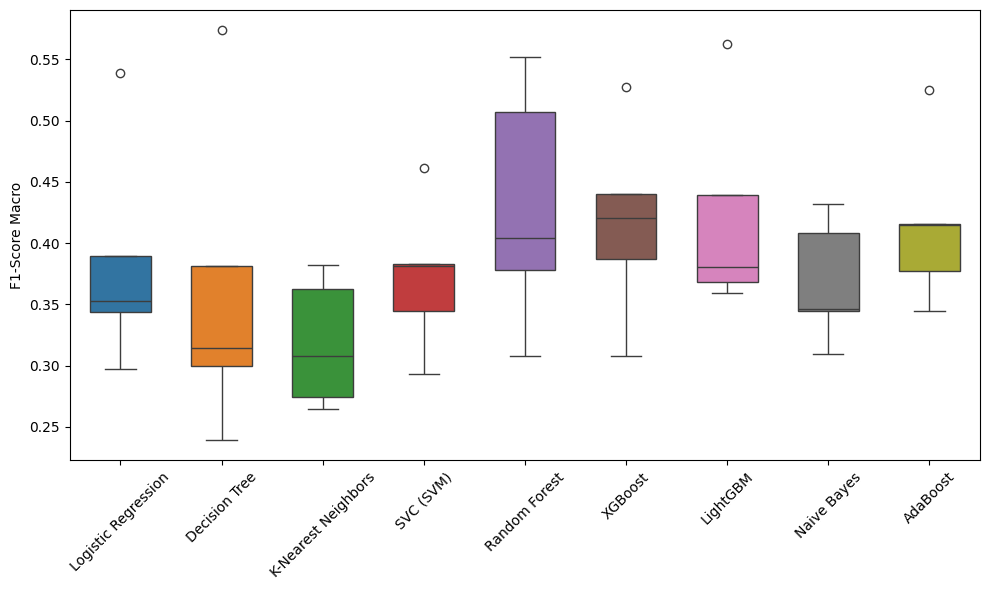

In [61]:
#codigo cogido de los apuntes de mi tutor, lo único que he cambiado es el estadistico que se va a maximizar.
#en mi caso cojo f1_macro para que se tengan más en cuenta los valores de categorias con menos casos, como finalista y finalista de conferencia.
#si no usaba esto los modelos eran solamente buenos prediciendo que equipos no pasaban de primera ronda.
nested_f1_scores ={model: [] for model in models.keys()}
nested_roc_auc_scores ={model: [] for model in models.keys()}
nested_mae_scores ={model: [] for model in models.keys()}
best_params ={model: [] for model in models.keys()}
for train_idx, test_idx in outer_cv.split(X, y):
    X_train_outer, X_test_outer =X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test_outer =y[train_idx], y[test_idx]
    for model_name, model_info in models.items():
        grid_search =GridSearchCV(
            estimator =model_info["pipeline"],
            param_grid =model_info["param_distributions"],
            cv =inner_cv,
            scoring ="f1_macro",
            n_jobs =-1,
            verbose =1 )
        grid_search.fit(X_train_outer, y_train_outer)
        y_pred =grid_search.predict(X_test_outer)
        y_proba =grid_search.predict_proba(X_test_outer)
        f1 =f1_score(y_test_outer, y_pred, average ="macro")

        #estudiare el f1_macro, curva auc.roc ovr y los mejores parametros.
        roc_auc =roc_auc_score(y_test_outer, y_proba, multi_class ="ovr", labels =[0, 1, 2, 3])
        mae =mean_absolute_error(y_test_outer, y_pred)
        nested_f1_scores[model_name].append(f1)
        nested_roc_auc_scores[model_name].append(roc_auc)
        nested_mae_scores[model_name].append(mae)
        best_params[model_name].append(grid_search.best_params_)

print("\nResultados finales (Nested CV):")
plt.figure(figsize=(10, 6))
sns.boxplot(data=list(nested_f1_scores.values()), orient="v", width=0.6)
plt.xticks(range(len(nested_f1_scores.keys())), nested_f1_scores.keys(), rotation=45)
plt.ylabel("F1-Score Macro")
plt.tight_layout()
plt.show()

In [62]:
# cojo las evaluaciones de cada modelo y las ploteo en una tabla para comparar los modelos
summary_data = []
for model_name in models.keys():
    media_f1 = np.mean(nested_f1_scores[model_name])
    median_f1 = np.median(nested_f1_scores[model_name])
    std_f1 = np.std(nested_f1_scores[model_name])
    media_auc = np.mean(nested_roc_auc_scores[model_name])
    media_mae = np.mean(nested_mae_scores[model_name])

    std_muestral = np.std(nested_f1_scores[model_name], ddof=1)
    error = std_muestral / np.sqrt(5)
    int_confianza = stats.t.interval(0.95, df=4, loc=media_f1, scale=error)

    summary_data.append({
        "Modelo": model_name,
        "Media F1-score Macro": media_f1,
        "Mediana F1-score macro": median_f1,
        "Limite inf. F1-macro": int_confianza[0],
        "Limite sup F1-Score Macro": int_confianza[1],
        "ROC-AUC OVR": media_auc,
        "MAE": media_mae
    })

tabla_modelos = pd.DataFrame(summary_data)
tabla_modelos = tabla_modelos.sort_values(by="Media F1-score Macro", ascending=False).reset_index(drop=True)
tabla_modelos = tabla_modelos.round(4)
display.display(tabla_modelos)

#tambien voy a obtener y dar los valores mas comunes y mejores de los hiperparametros
print("\nAnálisis de Hiperparámetros en Nested CV:")

most_common_params = {}
for model_name, params in best_params.items():
    most_common_str = Counter(map(str, params)).most_common(1)[0][0]

    most_common_params[model_name] = eval(most_common_str)
    best_index = np.argmax(nested_f1_scores[model_name])
    best_performance_params = params[best_index]
    print(f"\n{model_name}:")
    print(f"  - Conjunto de hiperparámetros más frecuente: {most_common_params[model_name]}")
    print(f"  - Conjunto con mejor rendimiento en Outer CV: {best_performance_params}")

,Modelo,Media F1-score Macro,Mediana F1-score macro,Limite inf. F1-macro,Limite sup F1-Score Macro,ROC-AUC OVR,MAE
0,Random Forest,0.4296,0.4039,0.3066,0.5526,0.7089,0.6961
1,LightGBM,0.4221,0.3806,0.3169,0.5273,0.6978,0.7494
2,XGBoost,0.4166,0.4205,0.3171,0.5161,0.7032,0.6528
3,AdaBoost,0.4155,0.4149,0.3310,0.4999,0.6812,0.6578
4,Logistic Regression,0.3844,0.3527,0.2695,0.4993,0.6837,0.7882
5,SVC (SVM),0.3725,0.3812,0.2961,0.4490,0.6988,0.7837
6,Naive Bayes,0.3681,0.3458,0.3054,0.4307,0.6626,0.7836
7,Decision Tree,0.3616,0.3143,0.2016,0.5216,0.6047,0.8210
8,K-Nearest Neighbors,0.3182,0.3078,0.2533,0.3832,0.6366,0.7597



Análisis de Hiperparámetros en Nested CV:

Logistic Regression:
  - Conjunto de hiperparámetros más frecuente: {'model__C': 1.0, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
  - Conjunto con mejor rendimiento en Outer CV: {'model__C': 1.0, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Decision Tree:
  - Conjunto de hiperparámetros más frecuente: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_split': 3}
  - Conjunto con mejor rendimiento en Outer CV: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_split': 6}

K-Nearest Neighbors:
  - Conjunto de hiperparámetros más frecuente: {'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'distance'}
  - Conjunto con mejor rendimiento en Outer CV: {'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'distance'}

SVC (SVM):
  - Conjunto de hiperparámetros más frecuente: {'model__C': 100.0, 'model__kernel': 'linear'}
  - Conjunto con mejor ren

In [63]:
#calculo el número total de validaciones que se han hecho
n_splits_outer =5
n_splits_inner =3
total_trainings_validations ={}
for model_name, model_info in models.items():
    param_dist = model_info["param_distributions"]
    total_combinations = 0
    if isinstance(param_dist, list):
        for param_set in param_dist:
            total_combinations += np.prod([len(v) for v in param_set.values()])
    else:
        total_combinations = np.prod([len(v) for v in param_dist.values()])

    total_outer_trainings =n_splits_outer
    total_outer_validations =n_splits_outer
    total_inner_trainings =n_splits_outer * n_splits_inner * total_combinations
    total_inner_validations =n_splits_outer * n_splits_inner * total_combinations
    total_trainings_validations[model_name] ={
        "Entrenamientos Outer CV": total_outer_trainings,
        "Validaciones Outer CV": total_outer_validations,
        "Entrenamientos Inner CV": total_inner_trainings,
        "Validaciones Inner CV": total_inner_validations,
        "Total Entrenamientos": total_outer_trainings + total_inner_trainings,
        "Total Validaciones": total_outer_validations + total_inner_validations
    }
df_total_trainings_validations = pd.DataFrame(total_trainings_validations).T
df_total_trainings_validations.loc["Total General"] = df_total_trainings_validations.sum()
display.display(df_total_trainings_validations)


,Entrenamientos Outer CV,Validaciones Outer CV,Entrenamientos Inner CV,Validaciones Inner CV,Total Entrenamientos,Total Validaciones
Logistic Regression,5,5,45,45,50,50
Decision Tree,5,5,180,180,185,185
K-Nearest Neighbors,5,5,180,180,185,185
SVC (SVM),5,5,225,225,230,230
Random Forest,5,5,240,240,245,245
XGBoost,5,5,960,960,965,965
LightGBM,5,5,960,960,965,965
Naive Bayes,5,5,45,45,50,50
AdaBoost,5,5,270,270,275,275
Total General,45,45,3105,3105,3150,3150


In [64]:
datos_23_24 =pd.read_csv("temporada_23_24.csv")
#el objetivo de hacer esto es ver como se compartan los modelos prediciendo una temporada entera de la que no saben nada
#Voy a añadir ahora las conferencias puesto que la mitad de los equipos de cada fase deben ser de cada conferencia
datos_23_24["fase_alcanzada"] =datos_23_24["fase_alcanzada"].replace(4, 3)
y_23_24 =datos_23_24["fase_alcanzada"].values
x_23_24 =datos_23_24[X.columns]

In [65]:
datos_23_24 = pd.read_csv("temporada_23_24.csv")
#el objetivo de hacer esto es ver como se compartan los modelos prediciendo una temporada entera de la que no saben nada
#Voy a añadir ahora las conferencias puesto que la mitad de los equipos de cada fase deben ser de cada conferencia
datos_23_24["fase_alcanzada"] = datos_23_24["fase_alcanzada"].replace(4, 3)
y_23_24 = datos_23_24["fase_alcanzada"].values
x_23_24 = datos_23_24[X.columns]

#también voy a obligar a que haya para cada conferencia 4 equipos eliminados en primera ronda, 2 en segunda, 1 en tercera y un finalista
#para ello calculare la prob de acabar en cada fase y se multpilicara por el valor de cada fase. Mas tarde se colocoran de mayor a menor dandome asi la estructura real
modelos_finales = {}

tabla_predicciones = pd.DataFrame({
    "equipo": datos_23_24["equipo"],
    "realidad": y_23_24
})

for name, info in models.items():
    par_com = most_common_params[name]

    modelo_final = clone(info["pipeline"])
    modelo_final.set_params(**par_com)
    modelo_final.fit(X, y)

    prob = modelo_final.predict_proba(x_23_24)
    esperanza = prob[:, 0]*0 + prob[:, 1]*1 + prob[:, 2]*2 + prob[:, 3]*3
    temp_df = pd.DataFrame({
        "conferencia": datos_23_24["conferencia"],
        "esperanza": esperanza
    })
    predicciones_modelo = np.zeros(len(datos_23_24), dtype=int)
    for conf in ["Este", "Oeste"]:
        indices = temp_df[temp_df["conferencia"] == conf].index
        indices_ordenados = temp_df.loc[indices].sort_values(by="esperanza", ascending=False).index
        predicciones_modelo[indices_ordenados[0]] = 3
        predicciones_modelo[indices_ordenados[1]] = 2
        predicciones_modelo[indices_ordenados[2]] = 1
        predicciones_modelo[indices_ordenados[3]] = 1
        predicciones_modelo[indices_ordenados[4]] = 0
        predicciones_modelo[indices_ordenados[5]] = 0
        predicciones_modelo[indices_ordenados[6]] = 0
        predicciones_modelo[indices_ordenados[7]] = 0
    tabla_predicciones[name] = predicciones_modelo
    modelos_finales[name] = modelo_final

#voy a poner en una tabla los valores reales de la temporada_23_24 y las predicciones de cada modelo
tabla_predicciones = tabla_predicciones.sort_values(by="realidad", ascending=False)
tabla_predicciones = tabla_predicciones.set_index("equipo")
tabla_numerica = tabla_predicciones.copy()
map_texto = {
    0: "1ra Ronda",
    1: "Semis Conf.",
    2: "Final Conf.",
    3: "Finalista"
}
tabla_display = tabla_predicciones.copy()
for col in tabla_display.columns:
    tabla_display[col] = tabla_display[col].map(map_texto)
display.display(tabla_display)

#voy a crear ahora una tabla que me diga cuantos aciertos ha conseguido cada modelo y cuantos fallos a 1 2 o 3 fases ha tenido.
#con los aciertos y fallos haré una puntuación que favorezca a los modelos que consigan tener la mayoria de sus casos como mucho a una ronda y los penalice cuando se pasen.
resumen_precision = []
reales = tabla_numerica["realidad"].values
for name in models.keys():
    preds = tabla_numerica[name].values
    diff = np.abs(preds - reales)
    aciertos = np.sum(diff == 0)
    fallos_1 = np.sum(diff == 1)
    fallos_2 = np.sum(diff == 2)
    fallos_3 = np.sum(diff == 3)
    condiciones = [diff == 0, diff == 1, diff == 2, diff == 3]
    valores = [1.0, 0.5, -0.5, -1]
    puntos = np.select(condiciones, valores, default=0.0)
    precision_custom = np.mean(puntos)
    resumen_precision.append({
        "Modelo": name,
        "Aciertos": aciertos,
        "Fallos 1": fallos_1,
        "Fallos 2": fallos_2,
        "Fallos 3": fallos_3,
        "Precisión Personalizada": precision_custom
    })

tabla_resumen = pd.DataFrame(resumen_precision)
tabla_resumen = tabla_resumen.sort_values(by="Precisión Personalizada", ascending=False)
display.display(tabla_resumen)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,realidad,Logistic Regression,Decision Tree,K-Nearest Neighbors,SVC (SVM),Random Forest,XGBoost,LightGBM,Naive Bayes,AdaBoost
equipo,,,,,,,,,,
Boston Celtics,Finalista,Finalista,1ra Ronda,Finalista,Finalista,Finalista,Finalista,Final Conf.,Semis Conf.,Finalista
Dallas Mavericks,Finalista,1ra Ronda,Semis Conf.,1ra Ronda,1ra Ronda,1ra Ronda,1ra Ronda,1ra Ronda,1ra Ronda,1ra Ronda
Indiana Pacers,Final Conf.,1ra Ronda,Semis Conf.,Final Conf.,1ra Ronda,Final Conf.,Semis Conf.,Semis Conf.,Finalista,Final Conf.
Minnesota Timberwolves,Final Conf.,Semis Conf.,Finalista,Final Conf.,Final Conf.,Final Conf.,Finalista,1ra Ronda,Semis Conf.,Semis Conf.
Denver Nuggets,Semis Conf.,1ra Ronda,1ra Ronda,Semis Conf.,1ra Ronda,Semis Conf.,1ra Ronda,Semis Conf.,1ra Ronda,1ra Ronda
Oklahoma City Thunder,Semis Conf.,Semis Conf.,1ra Ronda,Semis Conf.,Finalista,Finalista,Semis Conf.,Final Conf.,Final Conf.,Finalista
New York Knicks,Semis Conf.,1ra Ronda,1ra Ronda,1ra Ronda,1ra Ronda,1ra Ronda,1ra Ronda,1ra Ronda,1ra Ronda,Semis Conf.
Cleveland Cavaliers,Semis Conf.,Final Conf.,Semis Conf.,1ra Ronda,Final Conf.,Semis Conf.,Final Conf.,Finalista,Final Conf.,1ra Ronda
Miami Heat,1ra Ronda,1ra Ronda,Finalista,Semis Conf.,Semis Conf.,1ra Ronda,1ra Ronda,Semis Conf.,1ra Ronda,1ra Ronda


,Modelo,Aciertos,Fallos 1,Fallos 2,Fallos 3,Precisión Personalizada
4,Random Forest,11,3,1,1,0.68750
2,K-Nearest Neighbors,10,4,0,2,0.62500
5,XGBoost,7,7,1,1,0.56250
8,AdaBoost,8,5,2,1,0.53125
3,SVC (SVM),6,7,2,1,0.46875
7,Naive Bayes,5,8,1,2,0.40625
0,Logistic Regression,6,6,2,2,0.37500
6,LightGBM,6,6,2,2,0.37500
1,Decision Tree,5,6,3,2,0.28125
